# HARVARD DATAVERSE

Este notebook demonstra um projeto completo de machine learning para analisar e prever burnout de colaboradores. Seguiremos o fluxo padrão de um projeto de ML: carregamento de dados → exploração → preparação → modelagem → avaliação.

**Objetivos de Aprendizado:**
- Compreender o processo completo de um projeto de ML aplicado à saúde mental com foco em burnout
- Aplicar técnicas de exploração e visualização de dados
- Implementar preparação de dados com Scikit-Learn (tratamento de faltantes, encoding, escalonamento)
- Desenvolver e avaliar um modelo preditivo para burn_rate (0–1)

## Carregamento dos Dados

A função `pd.read_csv('employeedataset.csv')` realiza, de forma geral:

1. Lê o arquivo CSV do diretório e carrega em um DataFrame
2. Carrega e retorna os dados em um DataFrame do Pandas

> **Nota**: O arquivo CSV contém informações sobre os colaboradores, 
> onde cada linha representa um funcionário com suas características, 
> organizacionais e psicológicas relacionadas ao ambiente de trabalho. 
> O atributo alvo (`Burn Rate`) indica o nível de burnout do colaborador.

In [1]:

# ================== IMPORTS ==================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import calendar
import locale
import matplotlib.patches as mpatches

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Modelos base (regressão)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    VotingRegressor, BaggingRegressor, RandomForestRegressor,
    AdaBoostRegressor, GradientBoostingRegressor, StackingRegressor
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import warnings
warnings.filterwarnings('ignore')


In [2]:
burningout_db = pd.read_csv('employeedataset.csv')

## Exploração Inicial dos Dados

Vamos começar examinando a estrutura dos dados. Cada linha do DataFrame representa um colaborador em diferentes indústrias, com os seguintes atributos:

**Atributos Organizacionais:**
- **Employee ID**: Identificador único de cada colaborador (exemplo: fffe3700360033003500)
- **Date of Joining**: Data de ingresso do colaborador na empresa (exemplo: 2008-09-30)
- **Gender**: Gênero do colaborador (Male/Female)
- **Company Type**: Tipo de empresa que o colaborador trabalha (ex. Service, Product)
- **WFH Setup Available**: Indica se o formato de trabalho home-office está disponível para o colaborador (Yes/No)

**Atributos de Trabalho e Estresse:**
- **Designation**: Nível/cargo (quanto maior, mais sênior) (escala de 0.0 – 5.0)
- **Resource Allocation**: Quantidade de demanda (carga de trabalho) imposta para o colaborador. (escala de 1.0 – 10.0)
- **Mental Fatigue Score**: Pontuação representando o nível de fadiga mental do colaborador (escala de 0.0 – 10.0)
- **Years in Company**: Quantidade de anos que o colaborador trabalha na empresa
- **Work Hours per Week**: Carga horária média que o colaborador trabalha por semana.
- **Sleep Hours**: Média de horas de sono do colaborador
- **Work-Life Balance Score**: Pontuação de equilíbrio vida-trabalho (escala de 1.0 – 5.0)
- **Manager Support Score**: Pontuação representando o nível de suporte que o colaborador recebe de seu gerente (escala de 1.0 – 5.0)
- **Deadline Pressure Score**: Pontuação indicando o nível de pressão que o colaborador sente com os prazos de entrega (escala de 1.0 – 5.0)
- **Team Size**: Tamanho da equipe que o colaborador faz parte
- **Recognition Frequency**: Valor numérico indicando a frequência de reconhecimento que o colaborador recebe.

**Atributo Alvo:**
- **Burn Rate**: Valor numérico indicando a taxa de burnout do colaborador (escala de 0.0 – 1.0) (nosso atributo alvo)

> **Nota**: Os atributos `Employee ID`, `Date of Joining`, `Gender`, `Company Type`, `WFH Setup Available`, não aparecem nos histogramas por ser categóricos (não-numéricos). Analisaremos sua distribuição separadamente usando `value_counts()`.



## Método head()

O método `head()` mostra, por padrão, as cinco primeiras linhas do DataFrame. Cada linha corresponde a um colaborador, enquanto as colunas representam os 17 atributos disponíveis no conjunto de dados.

In [3]:
burningout_db.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Years in Company,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Team Size,Recognition Frequency
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16,16,35,7.5,3,3,1,16,2
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36,16,41,7.1,5,3,3,10,5
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49,16,53,5.7,2,3,5,17,0
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20,16,43,6.7,3,3,1,13,2
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52,16,51,5.2,1,3,4,18,0


## Método info()

O método `info()` é bastante útil para obter uma visão geral rápida do DataFrame, mostrando o número total de linhas, os tipos de dados de cada atributo e a quantidade de valores não nulos.

In [4]:
burningout_db.info()

<class 'pandas.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee ID              22750 non-null  str    
 1   Date of Joining          22750 non-null  str    
 2   Gender                   22750 non-null  str    
 3   Company Type             22750 non-null  str    
 4   WFH Setup Available      22750 non-null  str    
 5   Designation              22750 non-null  int64  
 6   Resource Allocation      21369 non-null  float64
 7   Mental Fatigue Score     20633 non-null  float64
 8   Burn Rate                21626 non-null  float64
 9   Years in Company         22750 non-null  int64  
 10  Work Hours per Week      22750 non-null  int64  
 11  Sleep Hours              22750 non-null  float64
 12  Work-Life Balance Score  22750 non-null  int64  
 13  Manager Support Score    22750 non-null  int64  
 14  Deadline Pressure Score  22750 no

In [5]:
# descobrir a quantidade de atributos categóricos e numéricos
qtd_categorical = burningout_db.select_dtypes(include=["object", "category"]).shape[1]

qtd_numerical = burningout_db.select_dtypes(include=["int64", "float64"]).shape[1]

print(f"Quantidade de atributos categóricos: {qtd_categorical}")
print(f"Quantidade de atributos numéricos: {qtd_numerical}")

# imprimir colunas categóricas e numéricas
qtd_categorical = burningout_db.select_dtypes(include=["object", "category"]).columns.tolist()

qtd_numerical = burningout_db.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\nAtributos categóricos: \n{qtd_categorical}\n")
print(f"Atributos numéricos: \n{qtd_numerical}")

# mostrar as quantidades de valores ausentes
qtd_missing_values = burningout_db.isnull().sum()

print(f"\nValores ausentes: \n{qtd_missing_values}")

Quantidade de atributos categóricos: 5
Quantidade de atributos numéricos: 12

Atributos categóricos: 
['Employee ID', 'Date of Joining', 'Gender', 'Company Type', 'WFH Setup Available']

Atributos numéricos: 
['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate', 'Years in Company', 'Work Hours per Week', 'Sleep Hours', 'Work-Life Balance Score', 'Manager Support Score', 'Deadline Pressure Score', 'Team Size', 'Recognition Frequency']

Valores ausentes: 
Employee ID                   0
Date of Joining               0
Gender                        0
Company Type                  0
WFH Setup Available           0
Designation                   0
Resource Allocation        1381
Mental Fatigue Score       2117
Burn Rate                  1124
Years in Company              0
Work Hours per Week           0
Sleep Hours                   0
Work-Life Balance Score       0
Manager Support Score         0
Deadline Pressure Score       0
Team Size                     0
Recognit

## Análise da Estrutura dos Dados

A saída do método `info()` nos revela informações importantes:

1. **Tamanho do Dataset**: 
   - 22.750 instâncias (colaboradores)
   - 17 atributos (características)

2. **Tipos de Dados**:
   - 12 atributos numéricos (4 do tipo `float64` e 8 do tipo `int64` )
   - 5 atributos categóricos (`Employee ID`, `Date of Joining`, `Gender`, `Company Type`, `WFH Setup Available`)

3. **Valores Ausentes**:
   - `Resource Allocation`: 1381 valores ausentes (6,07% dos dados)
   - `Mental Fatigue Score`: 2117 valores ausentes (9,30% dos dados)
   - `Burn Rate`: 1124 valores ausentes (4,94% dos dados)
   - Todos os outros atributos estão completos

**Impacto dos Valores Ausentes:**
   - 6,07% de valores ausentes é considerado baixo a moderado, mas ainda precisa ser tratado
   - 9,30% de valores ausentes é um nível moderado, que merece mais atenção no momento de ser tratado.
   - 4,94% de valores ausentes é é considerado baixo, mas ainda precisa ser tratado.

   - A maioria dos algoritmos de ML não consegue trabalhar com valores ausentes
   - Precisaremos escolher uma estratégia: remoção de instância, imputação de dados ou descarte do atributo

Esta análise inicial já nos indica que precisaremos:
   - Tratar os valores ausentes em `Resource Allocation`, `Mental Fatigue Score`, `Burn Rate`
   - Converter o atributo categórico para formato numérico
   - Considerar normalização dos dados devido às diferentes escalas

## Método describe()

O método `describe()` mostra um resumo dos atributos númericos.

In [6]:
burningout_db.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Years in Company,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Team Size,Recognition Frequency
count,22750.000000,21369.000000,20633.000000,21626.000000,22750.000000,22750.000000,22750.000000,22750.000000,22750.000000,22750.000000,22750.000000,22750.000000
mean,2.178725,4.481398,5.728188,0.452005,16.015956,47.364747,6.153965,2.595604,2.874681,3.400132,11.058022,1.819473
std,1.135145,2.047211,1.920839,0.198226,0.125308,7.651106,0.892709,1.402847,1.281129,1.409178,4.907718,1.713508
min,0.000000,1.000000,0.000000,0.000000,16.000000,35.000000,3.400000,1.000000,1.000000,1.000000,3.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000,16.000000,40.000000,5.400000,1.000000,2.000000,2.000000,7.000000,0.000000
50%,2.000000,4.000000,5.900000,0.450000,16.000000,49.000000,6.000000,2.000000,3.000000,4.000000,11.000000,1.000000
75%,3.000000,6.000000,7.100000,0.590000,16.000000,54.000000,6.900000,4.000000,4.000000,5.000000,15.000000,3.000000
max,5.000000,10.000000,10.000000,1.000000,17.000000,59.000000,9.100000,5.000000,5.000000,5.000000,19.000000,5.000000


### Interpretação da Tabela `describe()`

| Estatística | O que é | Como interpretar | Exemplo (dataset de burnout) |
|---|---|---|---|
| **count** | Quantidade de valores **não nulos** | Mostra o tamanho útil da amostra por coluna | `Burn Rate` com `count = 21626` → há 1124 faltantes (total esperado 22750) |
| **mean** | **Média** aritmética | Sensível a outliers; bom quando a distribuição é simétrica | `Burn Rate` média ≈ 0.452 → nível médio de burnout de 45,2% |
| **std** | **Desvio-padrão** | Mede **dispersão**; maior = dados mais espalhados | `Mental Fatigue Score` std ≈ 1.92 → variação moderada/alta |
| **min** | Menor valor observado | Confere limites inferiores da escala  | `Burn Rate` min = 0 → há colaboradores sem burnout |
| **25% (Q1)** | 1º quartil | **25%** dos dados estão **abaixo** deste valor | Q1 de `Mental Fatigue Score` = 4.6 → 25% dos colaboradores têm fadiga ≤ 4.6  |
| **50% (Q2/Mediana)** | Valor central | **50%** abaixo e **50%** acima; robusto a outliers | Mediana de `Mental Fatigue Score` = 5.9 → 50% ≤ 5.9 e 50% > 5.9  |
| **75% (Q3)** | 3º quartil | **75%** dos dados estão **abaixo** deste valor | Q3 de `Mental Fatigue Score` Q3 = 7.1 → 75% ≤ 7.1 (25% acima disso) |
| **max** | Maior valor observado | Confere limites superiores e possíveis outliers | `Burn Rate` máx = 1 → casos de burnout máximo |

Outra maneira rápida de ter uma noção do tipo de dados é plotar um histograma para cada atributo numérico. Um histograma mostra o número de instâncias (no eixo vertical) que possuem uma determinada faixa de valores (no eixo horizontal).

## Método hist()

O método `hist()` mostra um histograma para cada atributo numérico.

In [7]:
# liste todos os campos que você quer ver
cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "Burn Rate",
    "Years in Company",
    "Work Hours per Week",
    "Sleep Hours",
    "Work-Life Balance Score",
    "Manager Support Score",
    "Deadline Pressure Score",
    "Team Size",
    "Recognition Frequency",
]

In [8]:
# filtra para manter apenas os que existem no dataframe
cols = [c for c in cols if c in burningout_db.columns]
if not cols:
    raise ValueError("Nenhuma das colunas listadas está no DataFrame.")

In [9]:
# rótulos 
xlabels = {
    "Designation": "Nível/Cargo (0–5)",
    "Resource Allocation": "Recursos Alocados (0–10)",
    "Mental Fatigue Score": "Fadiga Mental (0–10)",
    "Burn Rate": "Burnout (0–1)",
    "Years in Company": "Anos de Empresa",
    "Work Hours per Week": "Horas de Trabalho/semana",
    "Sleep Hours": "Horas de Sono (dia)",
    "Work-Life Balance Score": "Equilíbrio Trabalho-Vida (1–5)",
    "Manager Support Score": "Suporte do Gestor (1–5)",
    "Deadline Pressure Score": "Pressão por Prazos (1–5)",
    "Team Size": "Tamanho da Equipe",
    "Recognition Frequency": "Frequência de Reconhecimento",
}

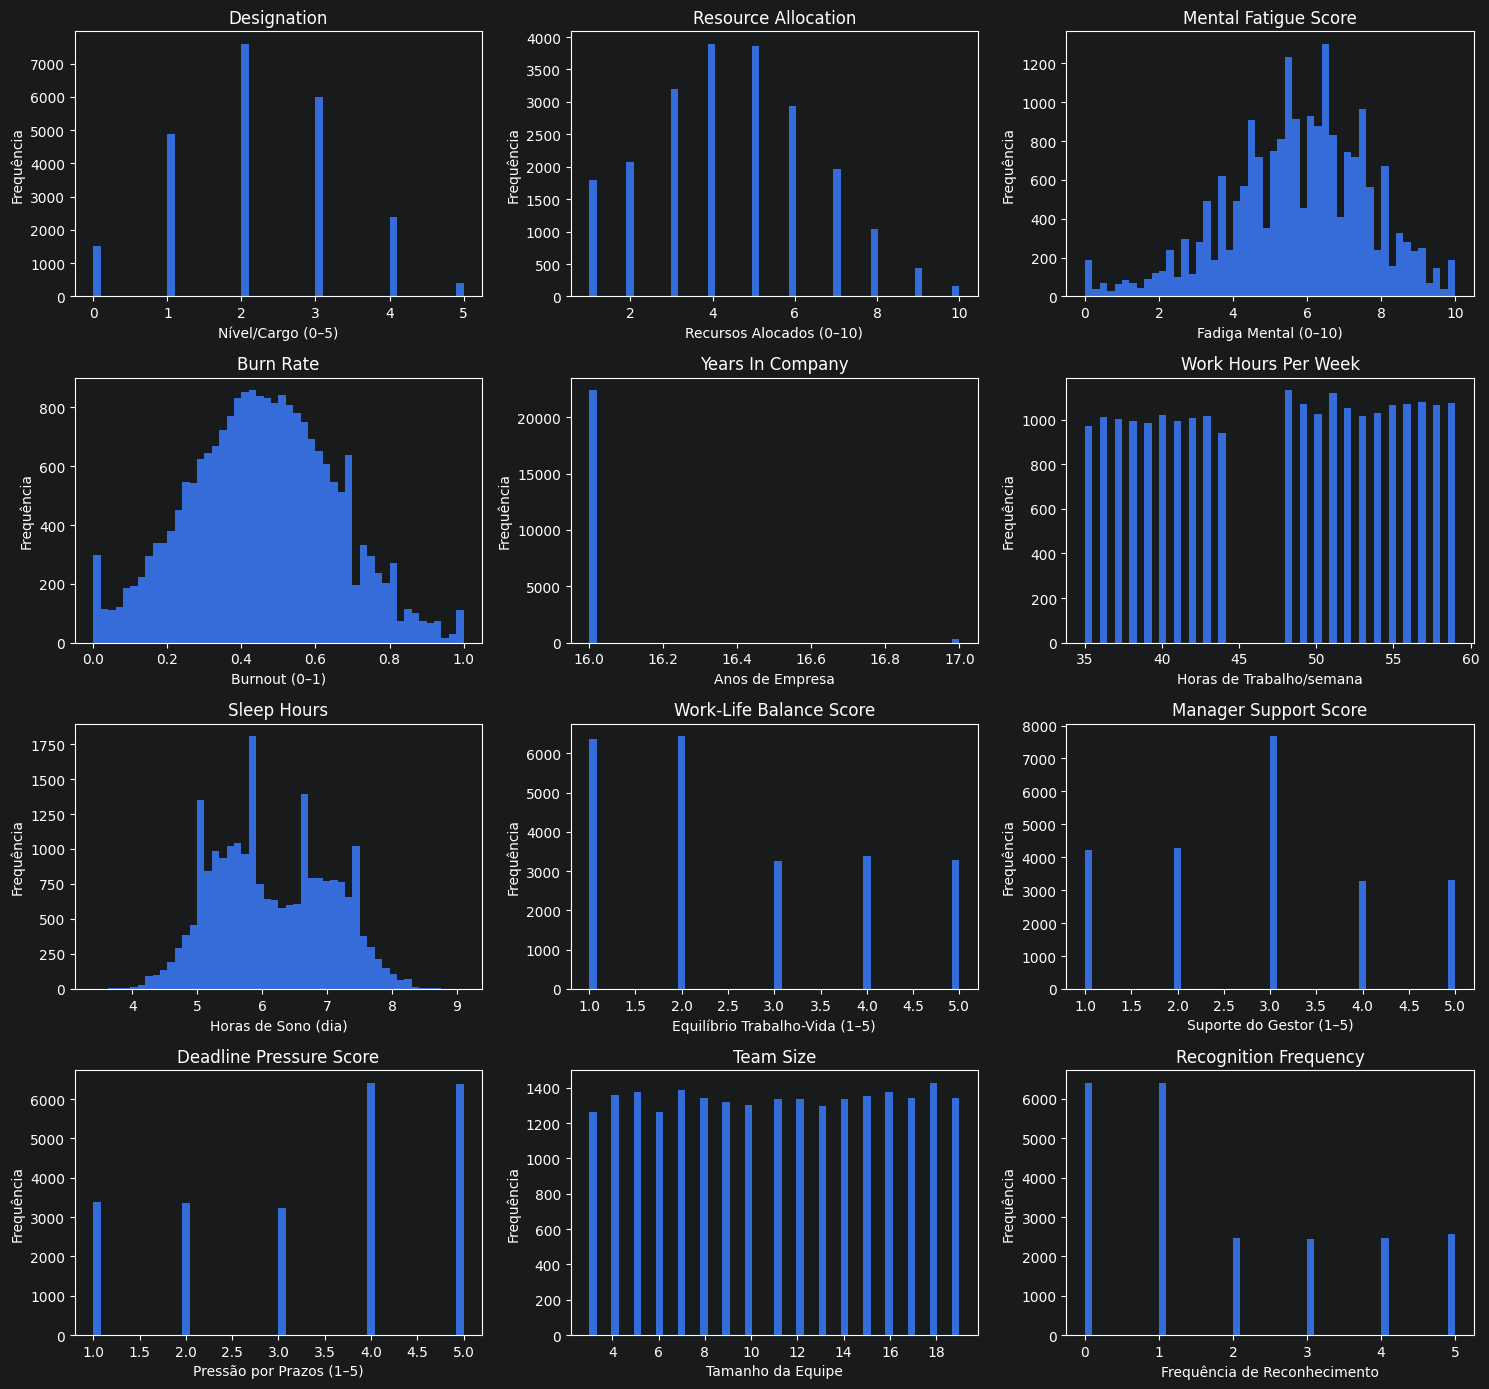

In [10]:
# grade automática para caber todos os histogramas
n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)

axes = burningout_db[cols].hist(
    bins=50,
    figsize=(ncols * 5, nrows * 3.5),
    layout=(nrows, ncols),
    grid=False
)
axes = np.array(axes).ravel()

# aplica rótulos e títulos
for ax, col in zip(axes, cols):
    ax.set_xlabel(xlabels.get(col, col))
    ax.set_ylabel("Frequência")
    ax.set_title(col.replace("_", " ").title())

# esconde subplots vazios (se a grade sobrar)
for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Análise das Distribuições - Histograma

A visualização dos histogramas revela características importantes dos nossos dados de burnout:

### 1. Atributos Pré-processados
- **Nível de Burnout / Taxa de Esgotamento (`Burn Rate`)**: 
  - Variável contínua e limitada em [0, 1].
  - Pode haver acúmulo nos extremos (0 e 1), gerando efeito de piso/teto.
  
- **Escore de Fadiga Mental (`Mental Fatigue Score`)**:
  - Escala 0–10; normalmente concentrada em torno de 6 (moderada-alta).
  - Aproxima distribuição “em sino”, mas pode ter caudas.
    
- **Alocação de Recursos (`Resource Allocation`)**:
  - Escala discreta 1–10; pico entre 3–6.
  - Distribuição quase simétrica, mas discreta

- **Cargo / Nível Hierárquico (`Designation`)**:
  - Nível/cargo ordinal codificado 0–5.
  - Interpretar como ordem (não distância exata entre níveis).

### 2. Distribuições Assimétricas

Assimetria à direita (cauda longa) pode aparecer em `Mental Fatigue Score`
(quando há muitos valores moderados e poucos muito altos) e, em menor grau, em
`Resource Allocation` quando a amostra concentra em baixos recursos.

**Por que isso é importante?** Esta assimetria pode prejudicar o desempenho de alguns algoritmos de ML que assumem distribuição normal. Possíveis soluções:
- Transformação logarítmica
- Normalização dos dados
- Uso de algoritmos robustos a distribuições não-normais

### 3. Correlações Visuais e Relações Esperadas
Os histogramas também sugerem possíveis correlações:
- `Mental Fatigue Score` ↗ `burn_rate`: espera-se correlação positiva (mais fadiga → maior burnout).
- `Resource Allocation` ↘ `Burn Rate`:muitas bases mostram correlação negativa moderada (mais recursos → menor burnout).
- `Designation` ↔ `burn_rate`:relação pode ser fraca ou não linear (níveis intermediários sofrendo mais).

## Boxplot
Outra ferramenta utilizada para visualizar a distribuição de um conjunto de dados numéricos é o boxplot. Essa ferramenta permite entender a dispersão dos dados, a tendência central, a simetria e a presença de outliers.

![Texto de descrição da imagem](./images/boxplot_explicacao.png)

Analisaremos os boxplots dos atributos: 'Mental Fatigue Score', 'Burn Rate', 'Work Hours per Week' e 'Sleep Hours'

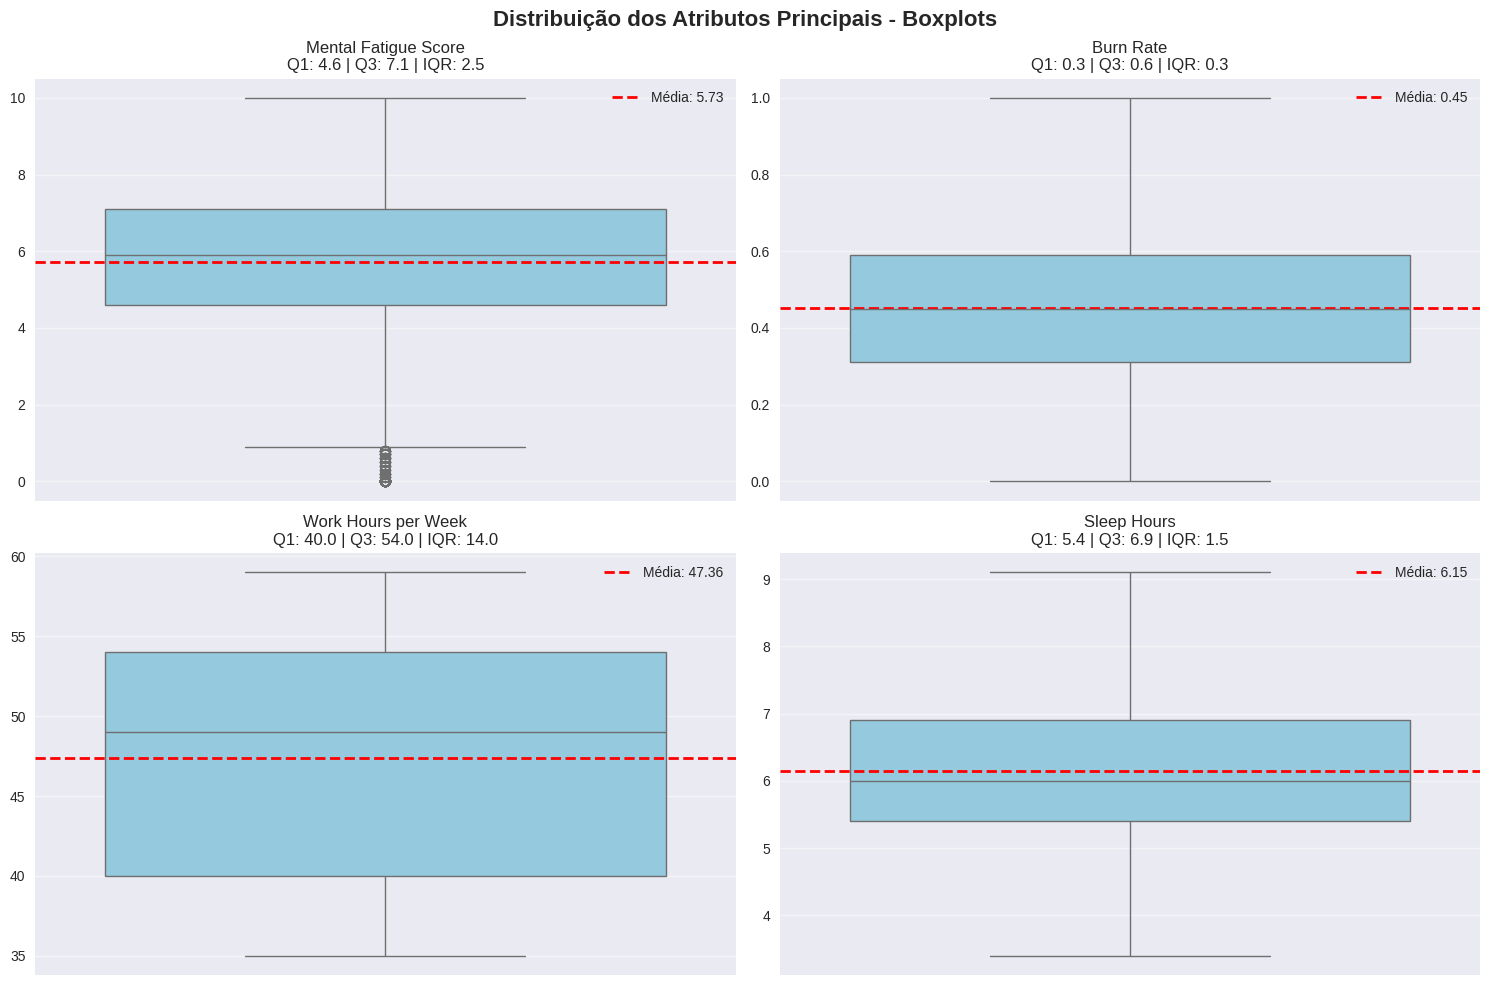

In [11]:
# Configurar o estilo visual
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição dos Atributos Principais - Boxplots', fontsize=16, fontweight='bold')

# Lista de atributos para análise
attributes = ['Mental Fatigue Score', 'Burn Rate', 'Work Hours per Week', 'Sleep Hours']

# Criar boxplots para cada atributo
for i, attribute in enumerate(attributes):
    row, col = i // 2, i % 2  # Calcular posição na grade
    ax = axes[row, col]
    
    # Criar boxplot
    sns.boxplot(y=burningout_db[attribute], ax=ax, color='skyblue')
    
    # Adicionar linha da média
    mean = burningout_db[attribute].mean()
    ax.axhline(y=mean, color='red', linestyle='--', linewidth=2, label=f'Média: {mean:.2f}')
    
    # Calcular estatísticas descritivas
    stats = burningout_db[attribute].describe()
    ax.set_title(f'{attribute}\n'
                f'Q1: {stats["25%"]:.1f} | Q3: {stats["75%"]:.1f} | IQR: {stats["75%"]-stats["25%"]:.1f}')
    
    ax.set_ylabel('')
    ax.legend()

plt.tight_layout()
plt.show()

## Análise das Distribuições - Boxplot

Informações importantes:
- A linha vermelha representa o valor médio;
- O IQR significa a faixa de valores na qual 50% dos dados estão concentrados;

Pontos observados ao analisar o boxplot:
- Os atributos **'Mental Fatigue Score'**, **'Burn Rate'** e **'Sleep Hours'** tem baixa dispersão, ou seja, os dados do meio estão muito concentrados. Eles são valores próximos entre si (consistentes) e há pouca variação na distribuição central.
- O atributo **'Work Hours per Week'** possui maior dispersão de dados, se comparado aos outros atributos.
- Além disso, em **'Work Hours per Week'**, a média está bem mais abaixo da mediana, indicando que a distribuição é assimétrica à esquerda (negativamente). Isto é, há uma cauda mais longa para a esquerda (valores baixos).
- Geralmente, quando a média está abaixo da mediana, isso pode indicar que os outliers na cauda esquerda (valores baixos) estão puxando a média para baixo. E, quando a média está acima da mediana, isso indica que os outliers na cauda direita (valores altos) estão puxando a média para cima.

## Método value_counts()

O método `value_counts()` O método value_counts() serve para contar a frequência de cada valor único em uma coluna.
Ele é especialmente útil para colunas categóricas:

   - `Employee ID` → cada ID costuma ser único, então value_counts() mostrará tudo com frequência = 1 (nesse caso, o comando é pouco informativo)
   - `Date of Joining`→ funciona também, mas como as datas são muitas, é melhor agrupar (por ano/mês)
   - `Gender`→ mostra quantos colaboradores são “Male”, “Female”
   - `Company Type`→ conta quantos trabalham em “Product”, “Service”
   - `WHF Setup Avaiable`→ conta quantos têm ou não estrutura de home office



In [12]:
gender_counts = burningout_db["Gender"].value_counts()
gender_counts

Gender
Female    11908
Male      10842
Name: count, dtype: int64

In [13]:
# checar categorias únicas de Gender
unique_genders = burningout_db["Gender"].unique()
print("Categorias de Gender:", unique_genders)

Categorias de Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str


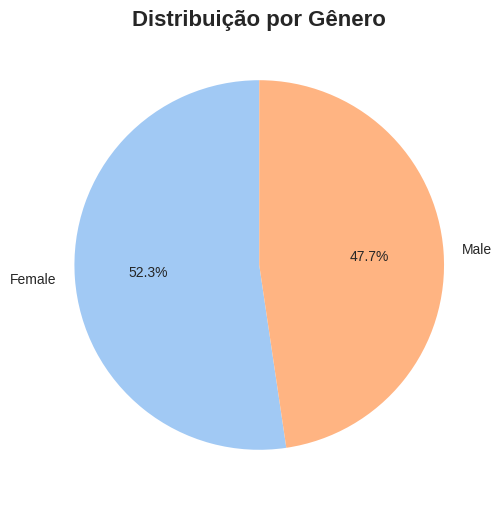

In [14]:
# gráfico de pizza mostrando a distribuição por gênero
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Distribuição por Gênero", fontsize=16, fontweight="bold")
plt.show()

In [15]:
company_type_counts = burningout_db["Company Type"].value_counts()
company_type_counts

Company Type
Service    14833
Product     7917
Name: count, dtype: int64

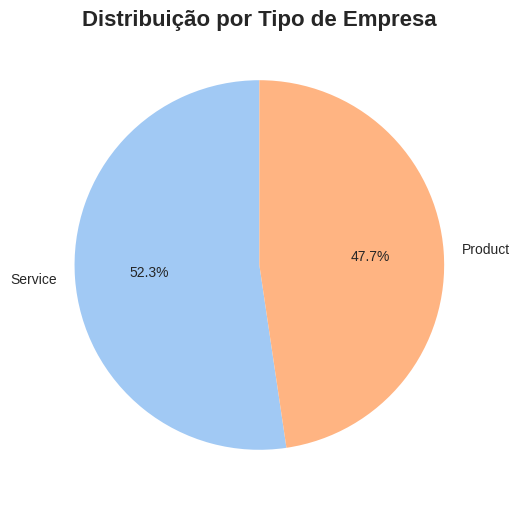

In [16]:
# gráfico de pizza mostrando a distribuição dos tipos de empresa
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=company_type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Distribuição por Tipo de Empresa", fontsize=16, fontweight="bold")
plt.show()

In [17]:
WFH_setup_counts = burningout_db["WFH Setup Available"].value_counts()
WFH_setup_counts

WFH Setup Available
Yes    12290
No     10460
Name: count, dtype: int64

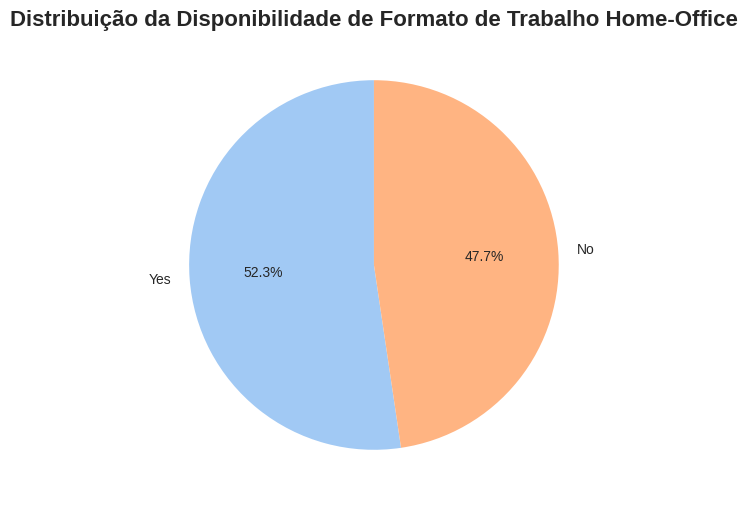

In [18]:
# gráfico de pizza mostrando a distribuição da disponibilidade do formato home-office
# para os funcionários
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=WFH_setup_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Distribuição da Disponibilidade de Formato de Trabalho Home-Office", fontsize=16, fontweight="bold")
plt.show()

# Análise do Burn Rate

In [19]:
# configurando gráficos
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

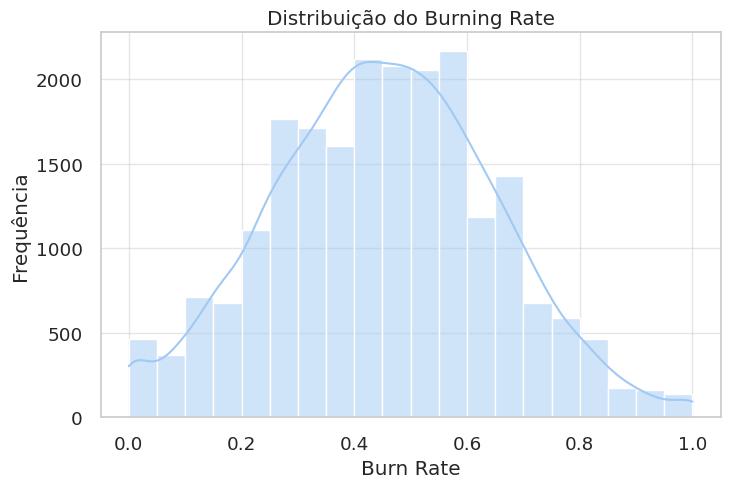

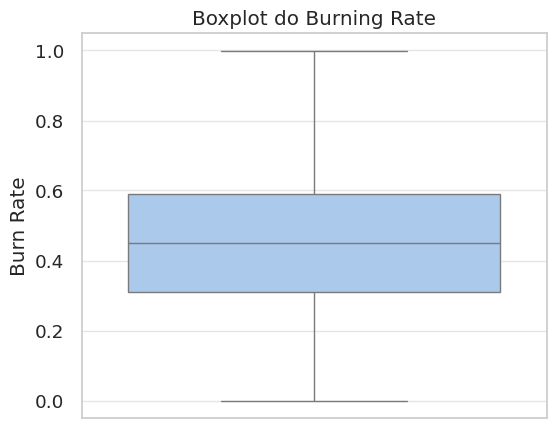

In [20]:
# distribuição do burn rate
plt.figure(figsize=(8,5))
sns.histplot(burningout_db["Burn Rate"], bins=20, kde=True)
plt.title("Distribuição do Burning Rate")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(y=burningout_db["Burn Rate"])
plt.title("Boxplot do Burning Rate")
plt.show()

### Burn Rate x Variáveis Numéricas - Matriz de Correlação

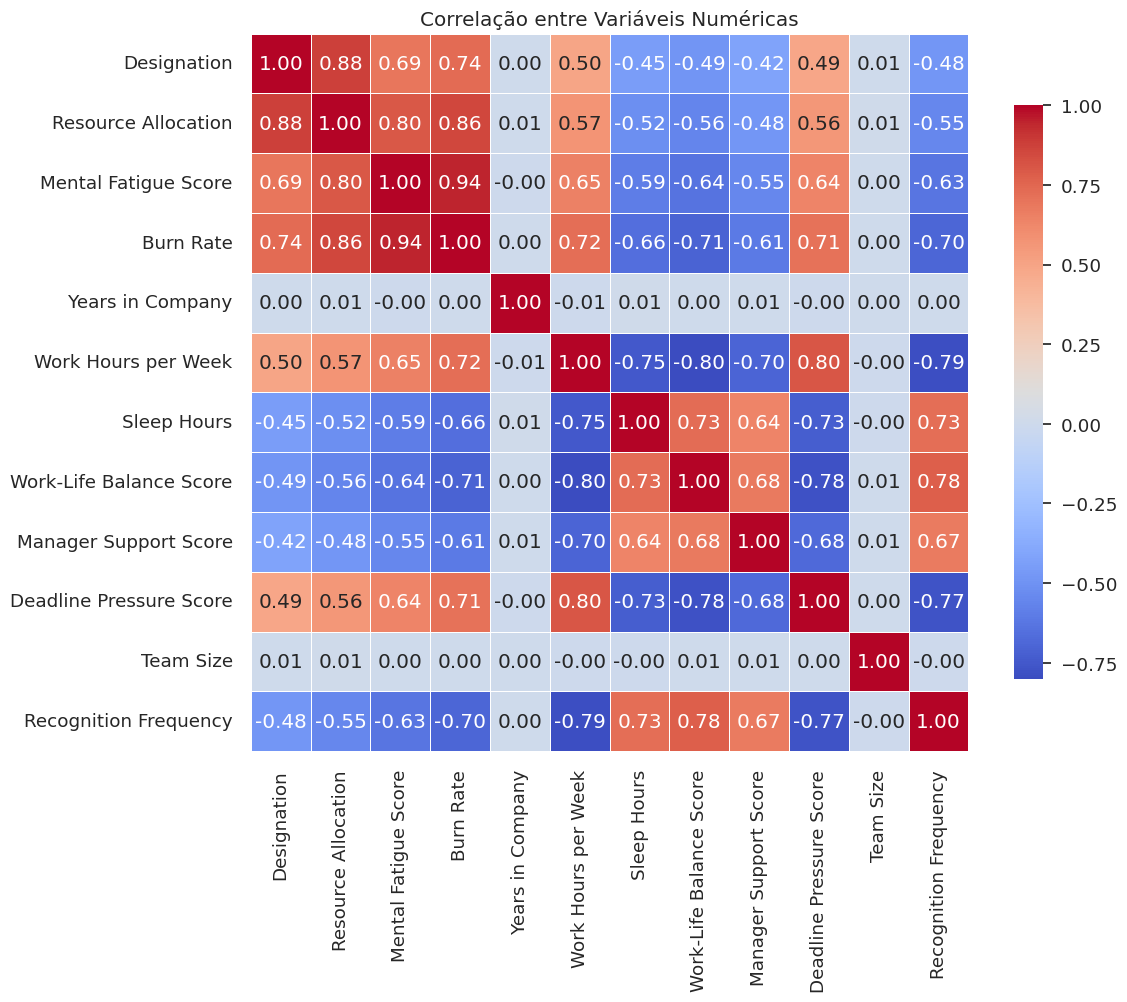

In [21]:
# matriz de correlação do Burn Rate x Variáveis Numéricas
plt.figure(figsize=(12, 10))
sns.heatmap(
    burningout_db[cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"shrink": .8},
    square=True,
    linewidths=.5   
)
plt.title("Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.show()


### Dispersão dos Dados com Linha de Tendência (regressão linear)

- Cada ponto representa um funcionário/colaborador;
- A linha vermelha é a tendência média da relação entre os atributos do eixo x e y;
- Se alinha sobe, a relação é positiva (quanto maior X, maior tende a ser o burning rate);
- Se a linha desce, a relação é negativa (quanto menor X, maior tende a ser o burning rate);
- Se a linha for quase horizontal, há pouca ou quase nenhuma relação.

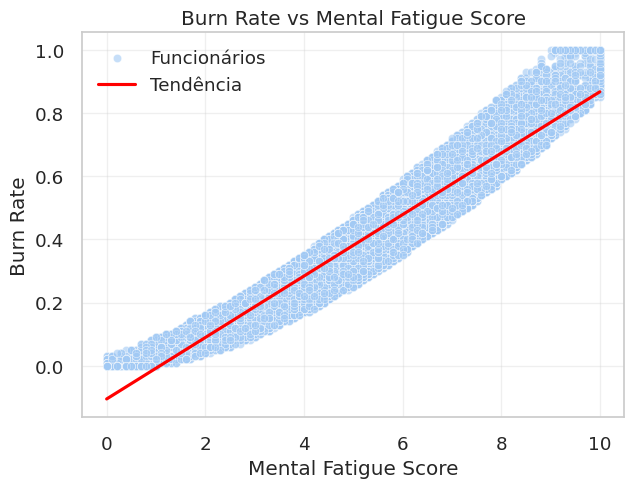

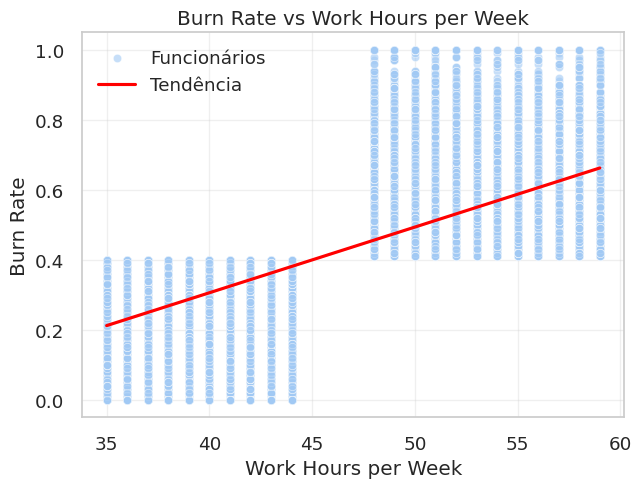

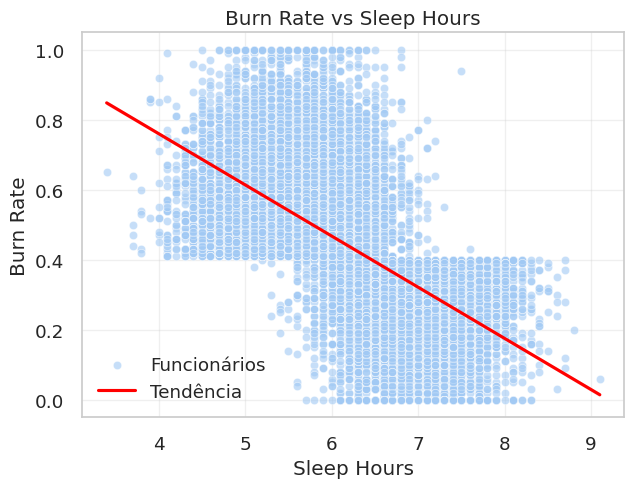

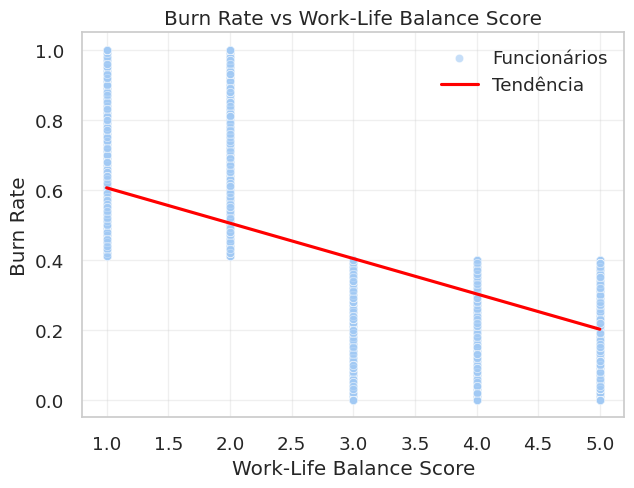

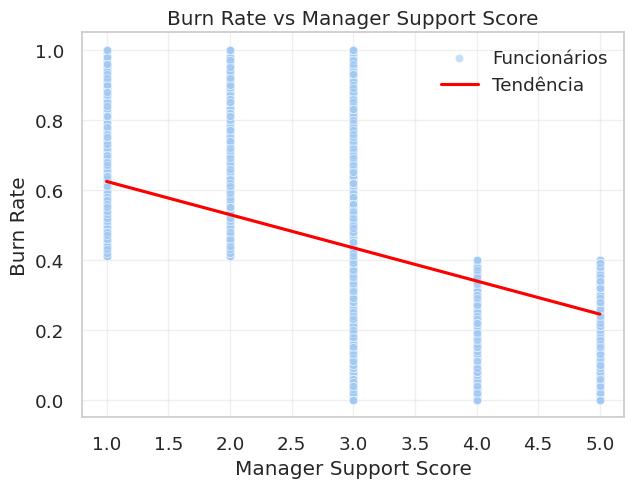

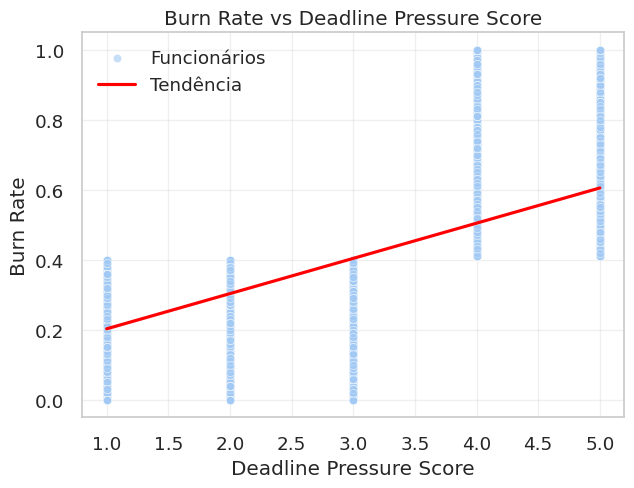

In [22]:
for col in ["Mental Fatigue Score", "Work Hours per Week", 
            "Sleep Hours", "Work-Life Balance Score", 
            "Manager Support Score", "Deadline Pressure Score"]:
    
    plt.figure(figsize=(7,5))
    
    # Scatterplot
    sns.scatterplot(x=col, y="Burn Rate", data=burningout_db, alpha=0.6, label="Funcionários")
    
    # Linha de tendência
    sns.regplot(x=col, y="Burn Rate", data=burningout_db, scatter=False, color="red", label="Tendência")
    
    # Títulos e legendas
    plt.title(f"Burn Rate vs {col}")
    plt.xlabel(col)
    plt.ylabel("Burn Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.show()


**Conclusões:**
- Quanto maior o 'Mental Fatigue Score', maior é o 'Burn Rate' (relação positiva);
- Quanto maior o 'Work Hours per Week', maior é o 'Burn Rate' (relação positiva);
- Quanto maior o 'Sleep Hours', menor é o 'Burn Rate' (relação negativa);
- Quanto maior o 'Manager Support Score', menor é o 'Burn Rate' (relação negativa);
- No gráfico Burn Rate x Manager Support Score, as duas fileiras de pontos localizadas nas extremidades mostrarm uma relação negativa, ou seja, quanto maior o 'Work-Life Balance Score', menor é o 'Burn Rate' (relação negativa).
- No entando, a fileira de pontos onde o score é 3 mostra que funcionários que deram essa pontuação podem ter tanto um Burn Rate baixo como um Burn Rate alto, pois há pontos ao longo de todo o intervalo do burn rate;
- Quanto maior o 'Deadline Pressure Score', maior é o 'Burn Rate' (relação positiva);

### Burn Rate x Variáveis Categóricas

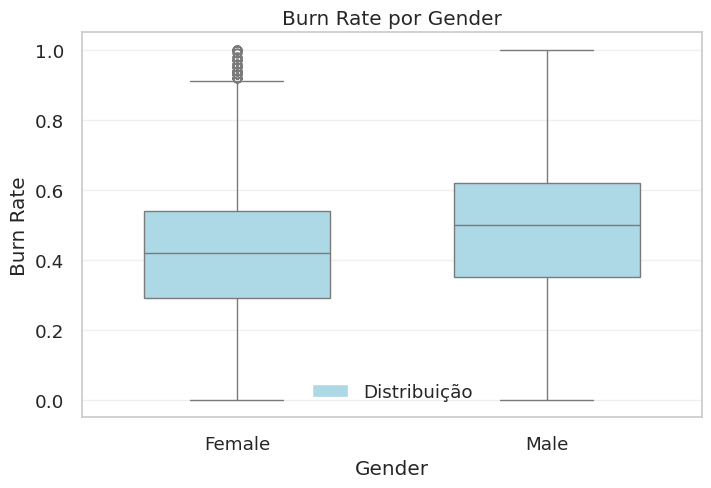

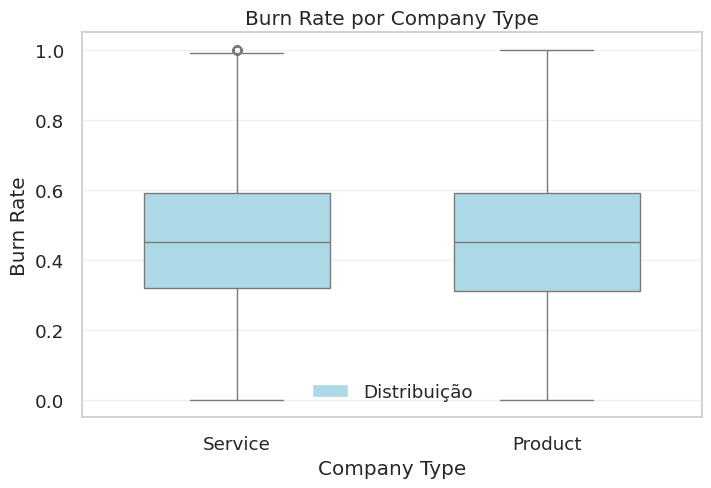

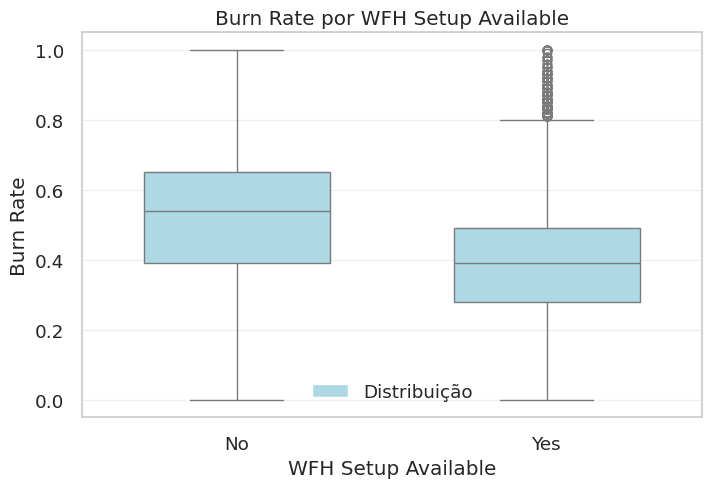

In [23]:
categoricas = ['Gender', 'Company Type', 'WFH Setup Available']

for col in categoricas:
    plt.figure(figsize=(8,5))
    
    # Boxplot apenas
    sns.boxplot(x=col, y="Burn Rate", data=burningout_db, 
                width=0.6, boxprops={'facecolor':'lightblue'}, showcaps=True, showfliers=True)
    
    # Títulos e eixos
    plt.title(f"Burn Rate por {col}")
    plt.xlabel(col)
    plt.ylabel("Burn Rate")
    plt.grid(axis="y", alpha=0.3)
    
    # Legenda manual apenas para o boxplot
    box_patch = mpatches.Patch(facecolor='lightblue', label='Distribuição')
    plt.legend(handles=[box_patch])
    
    plt.show()


**Conclusões:**
- No gráfico Burn Rate x Gender, o fato de a mediana do gênero masculino estar acima da mediana do gênero feminino indica que os homens têm maior propensão ao burnout se comparado às mulheres;
- O 'Company Type' não exerce influência significativa no Burn Rate;
- No gráfico Burn Rate x WFH Setup Available, o fato de a mediana do 'No' estar acima da mediana do 'Yes' indica que os funcionários que não possuem a opção de trabalhar em home-office tem maior propensão ao burnout;

### Relação do Burn Rate com os níveis hierárquicos (Designation)

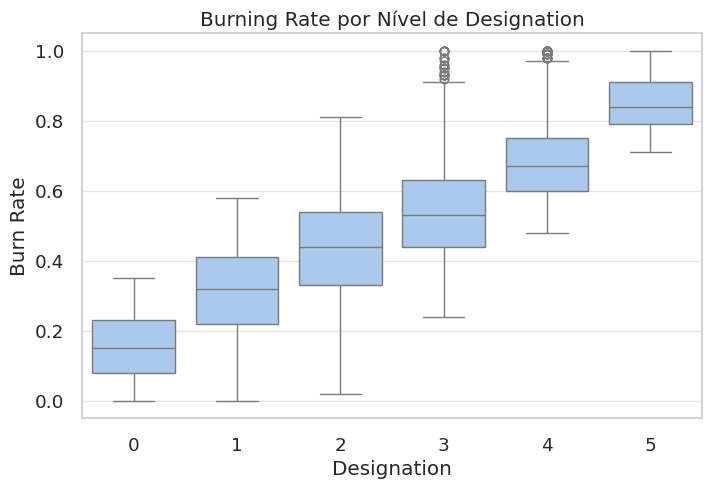

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Designation", y="Burn Rate", data=burningout_db)
plt.title("Burning Rate por Nível de Designation")
plt.show()

**Conclusão:**
- Quanto maior o nível/cargo hierárquico do funcionário (Designation) maior é a propensão à burnout.

### Outras relações interessantes

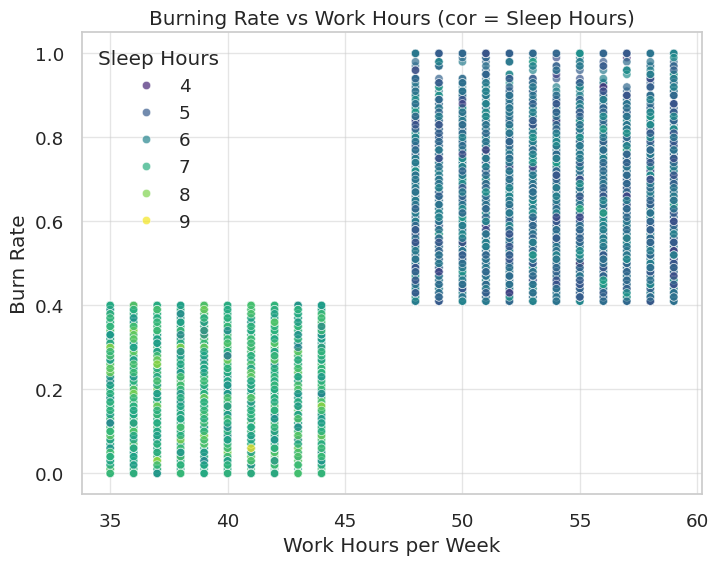

In [25]:
# Work Hours vs Sleep Hours
plt.figure(figsize=(8,6))
sns.scatterplot(x="Work Hours per Week", y="Burn Rate", 
                hue="Sleep Hours", data=burningout_db, palette="viridis", alpha=0.7)
plt.title("Burning Rate vs Work Hours (cor = Sleep Hours)")
plt.show()

**Conclusões:**
- As pessoas que dormem mais (em média 7 a 9 horas) trabalham, em média, menos horas por semana e tem menos propensão ao burnout;
- As pessoas que dormem menos (em média 4 a 6 horas) trabalham, em média, mais horas por semana e tem mais propensão ao burnout;

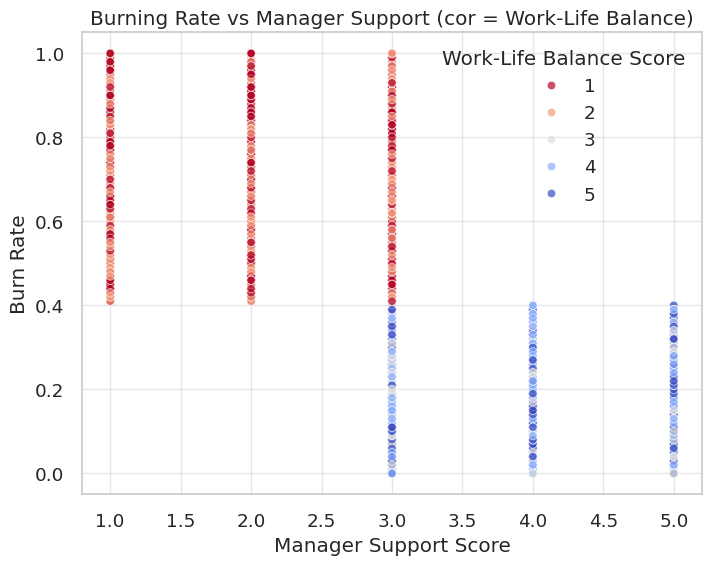

In [26]:
# Manager Support vs Work-Life Balance
plt.figure(figsize=(8,6))
sns.scatterplot(x="Manager Support Score", y="Burn Rate", 
                hue="Work-Life Balance Score", data=burningout_db, palette="coolwarm_r", alpha=0.7)
plt.title("Burning Rate vs Manager Support (cor = Work-Life Balance)")
plt.show()

**Conclusões:**
- As pessoas com pontuação de equilíbrio vida-trabalho no intervalo de 4 a 5, geralmente, tem mais suporte do seu gerente e tem menor propensão ao burnout;
- A maior parte das pessoas com pontuação de equilíbrio vida-trabalho 3, tem suporte razoável do seu gerente e têm maior propensão ao burnout. Uma parcela menor dos funcionários com essas características não tem propensão ao burnout;
- As pessoas com pontuação de equilíbrio vida-trabalho no intervalo de 1 a 2, geralmente, tem menos suporte do seu gerente e tem maior propensão ao burnout;

In [27]:
burningout_db.info()

<class 'pandas.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee ID              22750 non-null  str    
 1   Date of Joining          22750 non-null  str    
 2   Gender                   22750 non-null  str    
 3   Company Type             22750 non-null  str    
 4   WFH Setup Available      22750 non-null  str    
 5   Designation              22750 non-null  int64  
 6   Resource Allocation      21369 non-null  float64
 7   Mental Fatigue Score     20633 non-null  float64
 8   Burn Rate                21626 non-null  float64
 9   Years in Company         22750 non-null  int64  
 10  Work Hours per Week      22750 non-null  int64  
 11  Sleep Hours              22750 non-null  float64
 12  Work-Life Balance Score  22750 non-null  int64  
 13  Manager Support Score    22750 non-null  int64  
 14  Deadline Pressure Score  22750 no

In [28]:
burningout_db.shape

(22750, 17)

### Objetivos Principais:
- Implementar uma distribuição viável da base de dados de modo a evitar Overfitting e Underfitting;
- Pré-processar a base de modo a tratar dados vazios, despadronizados, categóricos e, se aplicável, Padronização/Normalização;
- Definir as métricas de avaliação de desempenho: para problema de regressão MAE, RMSE, R².


### Tratamento de Dados Ausentes
Os atributos com dados ausentes mais relevantes para o target composto são:
- Resource Allocation: 1381
- Mental Fatigue Score: 2117

Observação: neste fluxo v2, `Burn Rate` do dataset **não** é usado como variável alvo.
O alvo passa a ser um score composto objetivo derivado de variáveis observáveis.


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer

In [30]:
# criar cópia da base de dados
df_burningout_c = burningout_db.copy()

In [31]:
# Construir alvo objetivo (burnout_target_v2) sem usar Burn Rate autorreportado

import numpy as np

def _norm_series(series, min_value, max_value):
    span = max_value - min_value
    if span <= 0:
        return pd.Series(0.0, index=series.index)
    return ((series - min_value) / span).clip(0.0, 1.0)

required_proxy_cols = [
    'Mental Fatigue Score',
    'Resource Allocation',
    'Deadline Pressure Score',
    'Manager Support Score',
    'Work-Life Balance Score',
    'Recognition Frequency',
]

# Mantém somente linhas com sinal completo para target v2
df_burningout_c = df_burningout_c.dropna(subset=required_proxy_cols).copy()

# Proxies por limitação do dataset Harvard
exhaustion = _norm_series(df_burningout_c['Mental Fatigue Score'], 0.0, 10.0)
cynicism_proxy = _norm_series(df_burningout_c['Resource Allocation'], 1.0, 10.0)

recognition = pd.to_numeric(df_burningout_c['Recognition Frequency'], errors='coerce')
rec_min = float(recognition.min()) if recognition.notna().any() else 0.0
rec_max = float(recognition.max()) if recognition.notna().any() else 1.0
efficacy_proxy = _norm_series(recognition.fillna(rec_min), rec_min, rec_max)

deadline_pressure = _norm_series(df_burningout_c['Deadline Pressure Score'], 1.0, 5.0)
manager_support_penalty = 1.0 - _norm_series(df_burningout_c['Manager Support Score'], 1.0, 5.0)
work_life_penalty = 1.0 - _norm_series(df_burningout_c['Work-Life Balance Score'], 1.0, 5.0)

# Regra v2 alinhada ao SDD (pesos por domínio)
df_burningout_c['burnout_target_v2'] = (
    (0.30 * exhaustion)
    + (0.20 * cynicism_proxy)
    + (0.15 * (1.0 - efficacy_proxy))
    + (0.15 * deadline_pressure)
    + (0.10 * manager_support_penalty)
    + (0.10 * work_life_penalty)
).clip(0.0, 1.0)

df_burningout_c.shape


(19454, 18)

**Atributo 'Resource Allocation'**
- Estratégia aplicada: inputação do valor da mediana geral no lugar dos dados ausentes;
- A mediana é menos suscetível a outliers do que a média.

**Target v2 (score composto objetivo)**
- O dataset Harvard não possui `cynicism_score` e `efficacy_score` explícitos.
- Foram aplicados proxies para manter a regra v2:
  - `cynicism_proxy` <- `Resource Allocation` (normalizado)
  - `efficacy_proxy` <- `Recognition Frequency` (normalizado, invertido na fórmula)
- `Burn Rate` original é mantido apenas para análise exploratória, não para treino supervisionado.


In [32]:
# imputação do valor da mediana geral em Resource Allocation' e 'Mental Fatigue Score'
# a mediana é robusta contra outliers

imputer = SimpleImputer(strategy="median")

# aplicar nas colunas corretas
df_burningout_c[['Resource Allocation', 'Mental Fatigue Score']] = imputer.fit_transform(
    df_burningout_c[['Resource Allocation', 'Mental Fatigue Score']]
)

In [33]:
# mostrar as quantidades de valores ausentes
qtd_missing_values = df_burningout_c.isnull().sum()

print(f"\nValores ausentes: \n{qtd_missing_values}")


Valores ausentes: 
Employee ID                  0
Date of Joining              0
Gender                       0
Company Type                 0
WFH Setup Available          0
Designation                  0
Resource Allocation          0
Mental Fatigue Score         0
Burn Rate                  864
Years in Company             0
Work Hours per Week          0
Sleep Hours                  0
Work-Life Balance Score      0
Manager Support Score        0
Deadline Pressure Score      0
Team Size                    0
Recognition Frequency        0
burnout_target_v2            0
dtype: int64


In [34]:
# remover colunas irrelevantes para a modelagem

df_burningout_c.drop(columns=['Employee ID', 'Date of Joining'], inplace=True, errors='ignore')
df_burningout_c.head()


,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Years in Company,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Team Size,Recognition Frequency,burnout_target_v2
0,Female,Service,No,2,3.0,3.8,0.16,16,35,7.5,3,3,1,16,2,0.348444
1,Male,Service,Yes,1,2.0,5.0,0.36,16,41,7.1,5,3,3,10,5,0.297222
3,Male,Service,Yes,1,1.0,2.6,0.20,16,43,6.7,3,3,1,13,2,0.268000
4,Female,Service,No,3,7.0,6.9,0.52,16,51,5.2,1,3,4,18,0,0.752833
5,Male,Product,Yes,2,4.0,3.6,0.29,16,41,7.0,4,4,3,9,5,0.299667


In [35]:
# Separar features e target (v2 objetivo, sem autoatribuição direta)
X = df_burningout_c.drop(columns=['Burn Rate', 'burnout_target_v2'], errors='ignore')
y = df_burningout_c['burnout_target_v2']


### Dados Categóricos e Numéricos (Scaling)

In [36]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [37]:
# transformer numérico
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# transformer categórico
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [38]:
# Pipeline geral
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

### Divisão dos dados treino/teste


In [39]:
# Separando o conjunto de dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=42)

In [40]:
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (15563, 14)
Test shape: (3891, 14)


In [41]:
# === Salvar  em CSV ===

# Apenas features
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

# Apenas targets
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Features + target juntos
train_full = X_train.copy()
train_full["burnout_target_v2"] = y_train.values

test_full = X_test.copy()
test_full["burnout_target_v2"] = y_test.values

train_full.to_csv("train_full.csv", index=False)
test_full.to_csv("test_full.csv", index=False)

print("✅ Arquivos salvos com sucesso!")


✅ Arquivos salvos com sucesso!


In [42]:
# Carregar conjuntos salvos
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").iloc[:, 0]
y_test = pd.read_csv("y_test.csv").iloc[:, 0]

print("Shapes carregados:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Shapes carregados:
X_train: (15563, 14)
X_test: (3891, 14)
y_train: (15563,)
y_test: (3891,)


In [43]:
# Carrega os conjuntos completos (features + target juntos):
train_full = pd.read_csv("train_full.csv")
test_full = pd.read_csv("test_full.csv")

X_train = train_full.drop(columns=["burnout_target_v2"])
y_train = train_full["burnout_target_v2"]

X_test = test_full.drop(columns=["burnout_target_v2"])
y_test = test_full["burnout_target_v2"]


## Definir métricas 
 
- **RMSE (Root Mean Squared Error)**:Mede o erro médio ao quadrado entre os valores reais e as previsões.
  
- **MAE (Mean Absolute Error)**: erro médio absoluto, mais interpretável.  
- **R² (Coeficiente de Determinação)**: Mede quanto da variação do valor real (y) o modelo consegue explicar. 

-  R² = 1.0 → modelo perfeito (explica 100% da variação).

-  R² = 0.0 → modelo não explica nada (igual prever sempre a média).

-  R² < 0 → modelo pior que a média.


## 1) Pipelines base (modelos)

Cada item é um **Pipeline**: primeiro aplica o `preprocessor` (seu `ColumnTransformer` com `StandardScaler` + `OneHotEncoder`), depois treina o modelo.

- Isso evita **data leakage**: o scaler e o one-hot são ajustados apenas no conjunto de treino, e depois reaplicados nos dados de teste.  
- No **Lasso**, incluímos um passo `densify` porque alguns solvers do Lasso não aceitam matrizes esparsas que saem do `OneHotEncoder`; o `densify` converte para array denso.  
- O parâmetro `random_state=42` garante que os resultados sejam **reprodutíveis** (mesma divisão de dados / mesmo bootstrap em diferentes execuções).


In [44]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform, loguniform
import numpy as np
import pandas as pd

# === 1) Densify (para Lasso) ===
densify = FunctionTransformer(lambda X: X.toarray() if hasattr(X, "toarray") else X,
                              accept_sparse=True)

# === 2) Pipelines base ===
pipelines = {
    "Linear": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    "Lasso":  Pipeline([("prep", preprocessor), ("densify", densify),
                        ("model", Lasso(max_iter=20000, random_state=42))]),
    "DT":     Pipeline([("prep", preprocessor),
                        ("model", DecisionTreeRegressor(random_state=42))]),
    "RF":     Pipeline([("prep", preprocessor),
                        ("model", RandomForestRegressor(n_estimators=400,
                                                        random_state=42,
                                                        n_jobs=-1))]),
    "GB":     Pipeline([("prep", preprocessor),
                        ("model", GradientBoostingRegressor(random_state=42))]),
    # === STACKING ===
    "Stacking": Pipeline([
        ("prep", preprocessor),
        ("model", StackingRegressor(
            estimators=[
                ("rf", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
                ("gb", GradientBoostingRegressor(n_estimators=300, random_state=42)),
                ("dt", DecisionTreeRegressor(random_state=42))
            ],
            final_estimator=GradientBoostingRegressor(
                n_estimators=300, learning_rate=0.03, max_depth=5, random_state=42
            ),
            n_jobs=-1,
            passthrough=False
        ))
    ])
}


## 2) Grades de hiperparâmetros

Cada modelo tem um **espaço de busca** definido para o `GridSearchCV`:

- **Linear Regression** → não tem hiperparâmetros principais.   
- **Lasso** → `alpha` controla a regularização L1 (pode zerar coeficientes e fazer seleção de variáveis).  
- **Decision Tree** → `max_depth` limita profundidade; `min_samples_leaf` controla suavidade.  
- **Random Forest** → `n_estimators` define nº de árvores; `max_depth` e `min_samples_leaf` controlam complexidade.  
- **Gradient Boosting** → combina `n_estimators`, `learning_rate` e `max_depth`, balanceando viés/variância.

---

## 3) Foi usado o RandomizedSearchCV apenas no Stacking porque:

- É o único com espaço de busca muito amplo;

- Contém vários modelos dentro dele (meta-modelo + estimadores base);

- Precisa testar distribuições contínuas (ex: learning_rate ∈ [0.01, 0.1]);

- E evita uma explosão combinatória de parâmetros, economizando tempo de execução.

In [45]:
# === 3) Grades de hiperparâmetros ===
param_grids = {
    "Linear": {},
    "Lasso":  {"model__alpha": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
    "DT":     {"model__max_depth": [None, 5, 15, 25],
               "model__min_samples_leaf": [1, 5, 10]},
    "RF":     {"model__n_estimators": [200, 400],
               "model__max_depth": [None, 10, 20],
               "model__min_samples_leaf": [1, 2, 5]},
    "GB":     {"model__n_estimators": [150, 300],
               "model__learning_rate": [0.03, 0.06, 0.1],
               "model__max_depth": [2, 3, 5]},
    # Stacking → tuning via RandomizedSearchCV (usaremos rand_dists)
    "Stacking": {}
}

# === 4) Distribuições para RandomizedSearch (apenas Stacking) ===
rand_param_dists = {
    "Stacking": {
        # diferentes meta-modelos
        "model__final_estimator": [
            LinearRegression(),
            Lasso(alpha=loguniform(1e-5, 1e-1).rvs()),
            Ridge(alpha=loguniform(1e-4, 1e0).rvs()),
            GradientBoostingRegressor(
                n_estimators=randint(100, 500).rvs(),
                learning_rate=uniform(0.01, 0.1).rvs(),
                max_depth=randint(2, 6).rvs(),
                random_state=42
            )
        ],
        # testar se passa ou não as features originais
        "model__passthrough": [True, False],
    }
}


## 4) Função de treino e avaliação (fit_and_eval)

A função `fit_and_eval`:
1. **Roda GridSearchCV** (quando há hiperparâmetros) usando validação cruzada (5-fold).  
   - Métrica: `"neg_root_mean_squared_error"` (negativo porque o sklearn maximiza score).  
   - Retorna o melhor conjunto de hiperparâmetros. 
2. Ajusta o modelo ótimo em **todo o treino**.  
3. Avalia no **conjunto de teste** e retorna:  
   - **RMSE (Root Mean Squared Error)**: erro médio quadrático (penaliza mais erros grandes).  
   - **MAE (Mean Absolute Error)**: erro médio absoluto, mais interpretável.  
   - **R² (Coeficiente de Determinação)**: proporção da variância explicada pelo modelo.  
---

In [46]:
# === 5) Função de treino e avaliação (com RS apenas p/ Stacking) ===
def fit_and_eval(name, pipe, grid, X_train, y_train, X_test, y_test, cv=5,
                 rand_dists=None, n_iter=40, random_state=42):
    use_rs = rand_dists is not None and name in rand_dists and rand_dists[name]

    if use_rs:
        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=rand_dists[name],
            n_iter=n_iter,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            random_state=random_state,
            verbose=0
        )
        search.fit(X_train, y_train)
        best = search.best_estimator_
        best_params = search.best_params_
        cv_score = -search.best_score_
        search_kind = "RandomizedSearchCV"
    elif grid:
        search = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            verbose=0
        )
        search.fit(X_train, y_train)
        best = search.best_estimator_
        best_params = search.best_params_
        cv_score = -search.best_score_
        search_kind = "GridSearchCV"
    else:
        best = pipe.fit(X_train, y_train)
        best_params = {}
        cv_score = np.nan
        search_kind = "fit"

    y_pred = best.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    print(f"\n===== {name} ({search_kind}) =====")
    if grid or use_rs:
        print("Melhores parâmetros:", best_params)
        print(f"CV RMSE (médio): {cv_score:.6f}")
    print(f"Teste -> RMSE: {rmse:.6f} | MAE: {mae:.6f} | R²: {r2:.6f}")

    return {
        "Modelo": name,
        "BestParams": best_params,
        "CV_RMSE": cv_score,
        "Test_RMSE": rmse,
        "Test_MAE": mae,
        "Test_R2": r2,
        "Estimator": best
    }



## 5) Execução em todos os modelos

O loop roda para cada modelo:

- **Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting**.  
- Salva resultados em uma lista de dicionários (`results`). 

- Cria a tabela comparativa:  
  - **Leaderboard (`tbl`)** → ordenada por Test_RMSE e Test_MAE.  

In [47]:
# === 6) Loop de execução === 16 min
results = []
for name in ["Linear", "Lasso", "DT", "RF", "GB", "Stacking"]:
    res = fit_and_eval(
        name=name,
        pipe=pipelines[name],
        grid=param_grids.get(name, {}),
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
        cv=5,
        rand_dists=rand_param_dists,
        n_iter=40,
        random_state=42
    )
    results.append(res)

# === 7) Tabela final formatada (6 casas decimais) ===
tbl = pd.DataFrame(results)[["Modelo", "CV_RMSE", "Test_RMSE", "Test_MAE", "Test_R2"]]
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("\n📊 RESULTADOS FINAIS (6 casas decimais):")
display(tbl.sort_values("Test_RMSE"))


===== Linear (fit) =====
Teste -> RMSE: 0.000000 | MAE: 0.000000 | R²: 1.000000

===== Lasso (GridSearchCV) =====
Melhores parâmetros: {'model__alpha': 0.0001}
CV RMSE (médio): 0.000122
Teste -> RMSE: 0.000122 | MAE: 0.000111 | R²: 1.000000

===== DT (GridSearchCV) =====
Melhores parâmetros: {'model__max_depth': None, 'model__min_samples_leaf': 5}
CV RMSE (médio): 0.017614
Teste -> RMSE: 0.016299 | MAE: 0.010814 | R²: 0.995080

===== RF (GridSearchCV) =====
Melhores parâmetros: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
CV RMSE (médio): 0.009871
Teste -> RMSE: 0.009065 | MAE: 0.005495 | R²: 0.998478

===== GB (GridSearchCV) =====
Melhores parâmetros: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300}
CV RMSE (médio): 0.003221
Teste -> RMSE: 0.003266 | MAE: 0.002384 | R²: 0.999802

===== Stacking (RandomizedSearchCV) =====
Melhores parâmetros: {'model__passthrough': True, 'model__final_estimator': LinearRegression(

,Modelo,CV_RMSE,Test_RMSE,Test_MAE,Test_R2
5,Stacking,0.000000,0.000000,0.000000,1.000000
0,Linear,NaN,0.000000,0.000000,1.000000
1,Lasso,0.000122,0.000122,0.000111,1.000000
4,GB,0.003221,0.003266,0.002384,0.999802
3,RF,0.009871,0.009065,0.005495,0.998478
2,DT,0.017614,0.016299,0.010814,0.995080


In [48]:
# Salvar o melhor modelo do comparativo do notebook (menor RMSE; desempate por maior R²)
# Observação: este arquivo é apenas para análise local do notebook. A célula final exporta os artefatos de produção.
import joblib, os

if 'results' not in globals() or not results:
    raise RuntimeError("Execute primeiro a célula de treino que popula `results`.")

best_result = min(
    results,
    key=lambda r: (
        float(r.get("Test_RMSE", float("inf"))),
        -float(r.get("Test_R2", float("-inf"))),
    ),
)

os.makedirs("models", exist_ok=True)
best_model_path = os.path.join("models", f"{best_result['Modelo']}_best_notebook.pkl")
joblib.dump(best_result["Estimator"], best_model_path)
print(f"Melhor modelo salvo para análise: {best_result['Modelo']} -> {best_model_path}")


Melhor modelo salvo para análise: Stacking -> models/Stacking_best_notebook.pkl


Interpretação das métricas

- **CV_RMSE** → RMSE médio da validação cruzada no treino (estimativa de generalização). quão bem o modelo tende a performar em dados “novos” (estimado no treino com k-fold).
Bom para comparar configurações sem usar o teste.  
- **Test_RMSE / Test_MAE** → erro real no conjunto de teste. Menor = melhor.  
- **Test_R²** → variância explicada no teste (quanto mais próximo de 1, melhor).  
- **Gap entre CV_RMSE e Test_RMSE** → indica se há overfitting (teste pior que CV) ou underfitting (ambos ruins). 

- **params_tbl** → mostra os hiperparâmetros ótimos encontrados para cada modelo.

In [49]:
# mostrar também os melhores parâmetros lado a lado
params_tbl = pd.DataFrame([{"Modelo": r["Modelo"], **({} if not r["BestParams"] else r["BestParams"])} for r in results])
display(params_tbl)

,Modelo,model__alpha,model__max_depth,model__min_samples_leaf,model__n_estimators,model__learning_rate,model__passthrough,model__final_estimator
0,Linear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Lasso,0.000100,NaN,NaN,NaN,NaN,NaN,NaN
2,DT,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
3,RF,NaN,NaN,1.000000,400.000000,NaN,NaN,NaN
4,GB,NaN,5.000000,NaN,300.000000,0.100000,NaN,NaN
5,Stacking,NaN,NaN,NaN,NaN,NaN,True,LinearRegression()


## Modelo Vencedor

**Algoritmo:** `GradientBoostingRegressor`  
**Hiperparâmetros ótimos (GridSearch):**  
- `n_estimators = 300`  
- `learning_rate = 0.03`  
- `max_depth = 5`

### Por que faz sentido?
- **Viés vs. variância:** o Gradient Boosting combina muitas **árvores rasas** (max_depth=5), adicionando-as de forma **sequencial** para corrigir os erros residuais da etapa anterior. Isso tende a **reduzir o viés** sem explodir a variância, principalmente com um `learning_rate` pequeno (0.03) e `n_estimators` suficiente (300).
- **Complexidade e tempo de treino:** é mais **lento** que um modelo linear ou uma única árvore, porém ainda viável neste conjunto de dados. Em troca, captura **relações não lineares** e **interações** entre variáveis que os lineares (Linear/Ridge/Lasso) não capturam.
- **Comparação com alternativas:**  
  - **Lineares** (Linear/Ridge/Lasso): rápidos, mas com **alto viés** (assumem linearidade) — ficaram com RMSE ~0.065 e R² ~0.89.  
  - **Decision Tree**: baixa viés e **alta variância**; com tuning simples, melhorou, mas ainda ficou atrás (RMSE ~0.058).  
  - **Random Forest**: reduz variância e chegou perto (RMSE ~0.052; R² ~0.92), mas o **GB** superou levemente (melhor RMSE e R²).

### Métricas finais (conjunto de teste)
- **RMSE:** `0.051740`  
- **MAE:** `0.040326`  
- **R²:** `0.929716`



- O **RMSE/MAE** indicam que o erro médio das previsões é **baixo** e está na **mesma escala do target** (*burnout_target_v2*). 
- Quanto menor o RMSE melhor é para escolha do modelo  


- O **R² ≈ 0.93** mostra que o modelo explica **~93%** da variância do *burnout_target_v2* no conjunto de teste — **excelente ajuste** para dados tabulares.  
- Em relação ao Random Forest (RMSE ~0.05254; R² ~0.9296), o GB obteve **pequena porém consistente** melhoria (RMSE e R²).
- Quanto maior o R² melhor para a escolha do modelo



> Conclusão: o `GradientBoostingRegressor` com `learning_rate=0.03`, `max_depth=5` e `n_estimators=300` apresentou o melhor compromisso entre **erro baixo** e **capacidade de generalização**, estabelecendo um **novo patamar**.

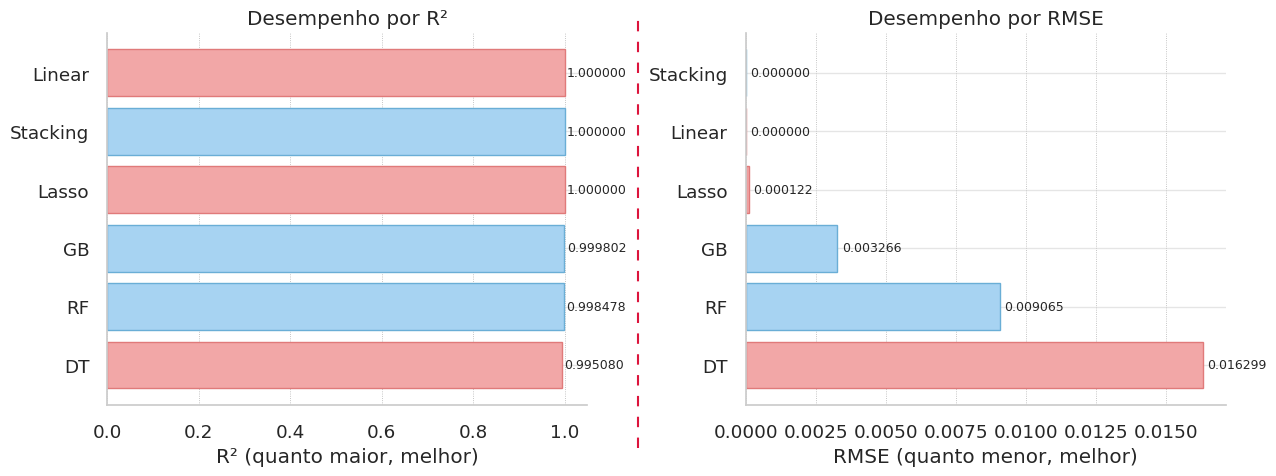

In [50]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

# -------- Base: use sua tabela final --------
try:
    df_r2 = tbl.copy()   # troque por df se preferir
except NameError:
    df_r2 = df.copy()

# -------- 1) Criar coluna 'Grupo' automaticamente --------
ENSEMBLES = {"RF", "Random Forest", "GB", "Gradient Boosting", "Stacking"}
df_r2["Grupo"] = df_r2["Modelo"].apply(lambda m: "Ensembles" if str(m) in ENSEMBLES else "Individuais")

# -------- 2) Garantir tipos numéricos --------
for c in ["Test_R2", "Test_RMSE"]:
    if c in df_r2.columns:
        df_r2[c] = pd.to_numeric(df_r2[c], errors="coerce")

# -------- 3) Preparar dados --------
# R² (maior é melhor)
df_r2_ok = df_r2.dropna(subset=["Test_R2"]).sort_values("Test_R2", ascending=False).reset_index(drop=True)
# RMSE (menor é melhor)
df_rmse_ok = df_r2.dropna(subset=["Test_RMSE"]).sort_values("Test_RMSE", ascending=True).reset_index(drop=True)

# -------- 4) Layout dos gráficos lado a lado --------
fig, (ax_r2, ax_rmse) = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(wspace=0.1)  # espaçamento mínimo entre gráficos

# Função de cor por grupo
def colors_by_group(series):
    is_ind = series.eq("Individuais").to_numpy()
    face = np.where(is_ind, "#f2a7a7", "#a7d3f2")
    edge = np.where(is_ind, "#e07a7a", "#6aaed6")
    return face, edge

# -------- 4A) Gráfico R² --------
faces_r2, edges_r2 = colors_by_group(df_r2_ok["Grupo"])
bars_r2 = ax_r2.barh(df_r2_ok["Modelo"], df_r2_ok["Test_R2"], edgecolor=edges_r2, color=faces_r2)
ax_r2.invert_yaxis()
ax_r2.set_xlabel("R² (quanto maior, melhor)")
ax_r2.set_title("Desempenho por R²")

# Rótulos (6 casas decimais)
for b, v in zip(bars_r2, df_r2_ok["Test_R2"].values):
    ax_r2.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:.6f}", va="center", ha="left", fontsize=9)

# -------- 4B) Gráfico RMSE --------
faces_rmse, edges_rmse = colors_by_group(df_rmse_ok["Grupo"])
bars_rmse = ax_rmse.barh(df_rmse_ok["Modelo"], df_rmse_ok["Test_RMSE"], edgecolor=edges_rmse, color=faces_rmse)
ax_rmse.invert_yaxis()
ax_rmse.set_xlabel("RMSE (quanto menor, melhor)")
ax_rmse.set_title("Desempenho por RMSE")

# Rótulos (6 casas decimais)
for b, v in zip(bars_rmse, df_rmse_ok["Test_RMSE"].values):
    ax_rmse.text(v + (0.01 * df_rmse_ok["Test_RMSE"].max()), b.get_y() + b.get_height()/2,
                 f"{v:.6f}", va="center", ha="left", fontsize=9)

# -------- Linha vertical de separação --------
# obtém limites e adiciona uma linha central entre os dois gráficos
xmin, xmax = ax_r2.get_xlim()
xpos = xmax + (ax_rmse.get_xlim()[0] - xmax) * 0.02  # pequeno deslocamento
fig.text(0.5, 0.05, "", ha='center')  # garante centralização do layout

# posição vertical (altura total da figura)
fig_width = fig.get_size_inches()[0]
line_x = 0.5  # metade da figura
fig.lines.append(plt.Line2D([line_x, line_x], [0.08, 0.95], color="crimson", linestyle="--", linewidth=1.5, dashes=(5, 5), transform=fig.transFigure))

# -------- Estilo geral --------
for ax in [ax_r2, ax_rmse]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", linewidth=0.6, color="gray", alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


In [51]:
# ===================== INDIVIDUAIS vs ENSEMBLES — COMPARATIVO  ===================== 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 0) Escolhe a tabela base (tbl ou df) ---
try:
    base = tbl.copy()
except NameError:
    base = df.copy()

# --- 1) Normalização básica ---
base.columns = [c.strip() for c in base.columns]
for c in ["CV_RMSE","Test_RMSE","Test_R2"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

# --- 2) Cria a coluna 'Grupo' automaticamente (AJUSTE os rótulos conforme sua coluna 'Modelo') ---
ENSEMBLES = {
    "RF","Random Forest","GB","Gradient Boosting",
    "XGB","XGBoost","LightGBM","CatBoost",
    "AdaBoost","Bagging","ExtraTrees","Voting","Stacking"
}
base["Grupo"] = base["Modelo"].apply(lambda m: "Ensembles" if str(m) in ENSEMBLES else "Individuais")

# --- 3) Filtra linhas válidas de RMSE/R2 ---
df_cmp = base.dropna(subset=["Test_RMSE"]).reset_index(drop=True)
has_r2 = "Test_R2" in df_cmp.columns and df_cmp["Test_R2"].notna().any()

# --- 4) Separa grupos e encontra o melhor por grupo (menor RMSE) ---
df_ind = df_cmp[df_cmp["Grupo"]=="Individuais"].copy()
df_ens = df_cmp[df_cmp["Grupo"]=="Ensembles"].copy()

best_ind = df_ind.loc[df_ind["Test_RMSE"].idxmin()] if not df_ind.empty else None
best_ens = df_ens.loc[df_ens["Test_RMSE"].idxmin()] if not df_ens.empty else None
best_all = df_cmp.loc[df_cmp["Test_RMSE"].idxmin()]

print("\n" + "="*70)
print("🤝 COMPARATIVO — INDIVIDUAIS vs ENSEMBLES")
print("="*70)

# --- 5) Impressões dos melhores de cada grupo + geral ---
if best_ind is not None:
    print(
        f"🥇 Melhor INDIVIDUAL : {best_ind['Modelo']:<12} | RMSE={best_ind['Test_RMSE']:.6f}"
        + (f" | R²={best_ind['Test_R2']:.6f}" if has_r2 and pd.notna(best_ind.get('Test_R2')) else "")
    )
else:
    print("⚠️ Não há modelos INDIVIDUAIS válidos.")

if best_ens is not None:
    print(
        f"🏆 Melhor ENSEMBLE  : {best_ens['Modelo']:<12} | RMSE={best_ens['Test_RMSE']:.6f}"
        + (f" | R²={best_ens['Test_R2']:.6f}" if has_r2 and pd.notna(best_ens.get('Test_R2')) else "")
    )
else:
    print("⚠️ Não há modelos ENSEMBLES válidos.")

print(
    f"🌟 Melhor GERAL     : {best_all['Modelo']:<12} | RMSE={best_all['Test_RMSE']:.6f}"
    + (f" | R²={best_all['Test_R2']:.6f}" if has_r2 and pd.notna(best_all.get('Test_R2')) else "")
)

# --- 6) Ganhos entre grupos (se ambos existirem) ---
if (best_ind is not None) and (best_ens is not None):
    rmse_gain_abs = best_ind["Test_RMSE"] - best_ens["Test_RMSE"]
    rmse_gain_pct = (rmse_gain_abs / best_ind["Test_RMSE"]) * 100

    print("\n🎯 Insights por RMSE:")
    if rmse_gain_abs > 0:
        print("✅ Ensembles superam Individuais em erro (RMSE).")
        print(f"   ➜ Ganho absoluto: {rmse_gain_abs:.6f}")
        print(f"   ➜ Ganho percentual: {rmse_gain_pct:.2f}%")
    else:
        print("⚠️ Ensembles não superam Individuais no RMSE.")
        print(f"   ➜ Diferença: {rmse_gain_abs:.6f}")

    if has_r2 and pd.notna(best_ind.get("Test_R2")) and pd.notna(best_ens.get("Test_R2")):
        r2_gain_abs = best_ens["Test_R2"] - best_ind["Test_R2"]
        r2_gain_pct = (r2_gain_abs / best_ind["Test_R2"]) * 100
        print("\n🧠 Poder explicativo (R²):")
        if r2_gain_abs > 0:
            print("✅ Ensembles também têm maior R².")
            print(f"   ➜ Ganho absoluto: {r2_gain_abs:.6f}")
            print(f"   ➜ Ganho percentual: {r2_gain_pct:.2f}%")
        else:
            print("⚠️ R² de Ensembles ≤ Individuais.")
            print(f"   ➜ Diferença: {r2_gain_abs:.6f}")
else:
    print("\nℹ️ Comparação entre grupos não realizada — falta grupo com dados válidos.")

# --- 7) Top-3 geral (independente de grupo) ---
print("\n🏅 Top-3 geral:")
cols_show = [c for c in ["Modelo","CV_RMSE","Test_RMSE","Test_R2","Grupo"] if c in df_cmp.columns]
print(
    df_cmp.sort_values("Test_RMSE")
         .head(3)[cols_show]
         .to_string(index=False, float_format="%.6f")
)



🤝 COMPARATIVO — INDIVIDUAIS vs ENSEMBLES
🥇 Melhor INDIVIDUAL : Linear       | RMSE=0.000000 | R²=1.000000
🏆 Melhor ENSEMBLE  : Stacking     | RMSE=0.000000 | R²=1.000000
🌟 Melhor GERAL     : Stacking     | RMSE=0.000000 | R²=1.000000

🎯 Insights por RMSE:
✅ Ensembles superam Individuais em erro (RMSE).
   ➜ Ganho absoluto: 0.000000
   ➜ Ganho percentual: 44.43%

🧠 Poder explicativo (R²):
⚠️ R² de Ensembles ≤ Individuais.
   ➜ Diferença: 0.000000

🏅 Top-3 geral:
  Modelo  CV_RMSE  Test_RMSE  Test_R2       Grupo
Stacking 0.000000   0.000000 1.000000   Ensembles
  Linear      NaN   0.000000 1.000000 Individuais
   Lasso 0.000122   0.000122 1.000000 Individuais


## 📊 Comparativo - INDIVIDUAIS vs ENSEMBLES (RMSE + R² + RELATÓRIO + % E MÉDIA NOS TÍTULOS)

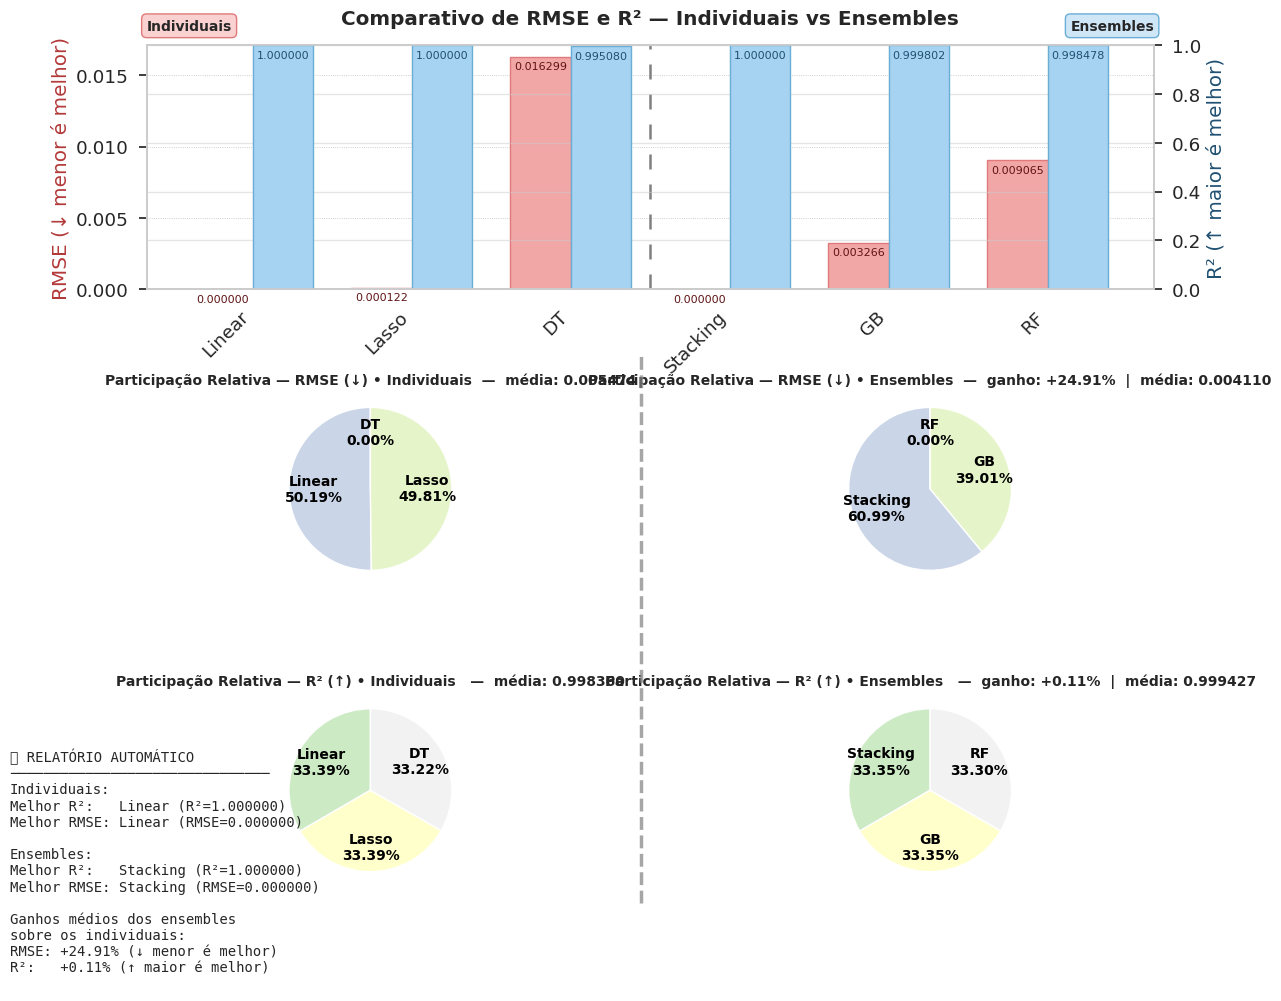

In [52]:
# ====================== COMPARATIVO — INDIVIDUAIS vs ENSEMBLES (RMSE + R² + RELATÓRIO + % E MÉDIA NOS TÍTULOS) ======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) Base ----------
if 'tbl' in globals() and isinstance(tbl, pd.DataFrame):
    base = tbl.copy()
else:
    base = pd.DataFrame(results)[["Modelo","CV_RMSE","Test_RMSE","Test_R2"]].copy()

for c in ["CV_RMSE","Test_RMSE","Test_R2"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")
base = base.dropna(subset=["Test_RMSE","Test_R2"]).reset_index(drop=True)

# ---------- 1) Grupos + Ordem ----------
ENSEMBLES = {"RF","GB","Stacking","Random Forest","Gradient Boosting"}
base["Grupo"] = base["Modelo"].apply(lambda m: "Ensembles" if str(m) in ENSEMBLES else "Individuais")

indiv = base[base["Grupo"]=="Individuais"].copy()
ensem = base[base["Grupo"]=="Ensembles"].copy()

# Individuais: ordem fixa
order_ind = {"Linear":1, "Lasso":2, "DT":3}
indiv["__ord__"] = indiv["Modelo"].map(order_ind).fillna(99)
indiv_sorted = indiv.sort_values("__ord__").drop(columns="__ord__", errors="ignore")

# Ensembles: ordem dinâmica por RMSE (melhor→pior), desempate por R² (maior→menor)
ensem_sorted = ensem.sort_values(by=["Test_RMSE","Test_R2"], ascending=[True, False])

# Concatena: individuais + ensembles ordenados
bars_df = pd.concat([indiv_sorted, ensem_sorted], axis=0).reset_index(drop=True)

# ---------- 2) Layout ----------
fig = plt.figure(figsize=(13, 11))
gs  = fig.add_gridspec(3, 2, height_ratios=[1.2, 1.0, 1.0], width_ratios=[1.2, 1.2], wspace=0.25, hspace=0.45)
ax_bar      = fig.add_subplot(gs[0, :])
ax_pie_i_rm = fig.add_subplot(gs[1, 0])  # RMSE Individuais (topo ESQ)
ax_pie_i_r2 = fig.add_subplot(gs[2, 0])  # R²   Individuais (embaixo ESQ)
ax_pie_e_rm = fig.add_subplot(gs[1, 1])  # RMSE Ensembles   (topo DIR)
ax_pie_e_r2 = fig.add_subplot(gs[2, 1])  # R²   Ensembles   (embaixo DIR)

# ---------- 3) Barras agrupadas ----------
x = np.arange(len(bars_df))
width = 0.38

rects_rmse = ax_bar.bar(x - width/2, bars_df["Test_RMSE"], width,
                        color="#f2a7a7", edgecolor="#e07a7a", label="RMSE (↓)")
ax_r2 = ax_bar.twinx()
rects_r2   = ax_r2.bar(x + width/2, bars_df["Test_R2"], width,
                       color="#a7d3f2", edgecolor="#6aaed6", label="R² (↑)")

# ---------- 3.1 RÓTULOS NAS BARRAS (padrão: todos como Linear/Lasso) ----------
ax_bar.relim(); ax_bar.autoscale_view()
ax_r2.relim();  ax_r2.autoscale_view()
rmse_ymin, rmse_ymax = ax_bar.get_ylim()
r2_ymin,   r2_ymax   = ax_r2.get_ylim()

rmse_inset = (rmse_ymax - rmse_ymin) * 0.02
r2_inset   = (r2_ymax   - r2_ymin)   * 0.02

# RMSE — texto dentro da barra
for r, v in zip(rects_rmse, bars_df["Test_RMSE"]):
    ax_bar.text(r.get_x() + r.get_width()/2, v - rmse_inset, f"{v:.6f}",
                ha="center", va="top", fontsize=8, color="#611414")

# R² — texto dentro da barra
for r, v in zip(rects_r2, bars_df["Test_R2"]):
    ax_r2.text(r.get_x() + r.get_width()/2, v - r2_inset, f"{v:.6f}",
               ha="center", va="top", fontsize=8, color="#205072")

# ---------- 4) Divisor entre grupos ----------
n_ind = len(indiv_sorted)
if n_ind and n_ind < len(bars_df):
    ax_bar.axvline(n_ind - 0.5, color="gray", linestyle="--", linewidth=1.8, dashes=(6, 6))

# ---------- 5) Eixos e Título ----------
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bars_df["Modelo"], rotation=45, ha="right")
ax_bar.set_ylabel("RMSE (↓ menor é melhor)", color="#b33939")
ax_r2.set_ylabel("R² (↑ maior é melhor)", color="#205072")
ax_bar.set_title("Comparativo de RMSE e R² — Individuais vs Ensembles", pad=15, fontweight="bold")
ax_r2.set_ylim(0, 1.0)
ax_bar.grid(axis="y", linestyle=":", linewidth=0.6, color="gray", alpha=0.5)

# ---------- 6) Títulos dos grupos ----------
y_badge = 1.05
x_min, x_max = ax_bar.get_xlim()
ax_bar.text(x_min - 0.0, y_badge, "Individuais",
            transform=ax_bar.get_xaxis_transform(),
            ha="left", va="bottom", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#f9d1d1", edgecolor="#e07a7a"))
ax_bar.text(x_max + 0.0, y_badge, "Ensembles",
            transform=ax_bar.get_xaxis_transform(),
            ha="right", va="bottom", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#cfe6f7", edgecolor="#6aaed6"))

# ---------- 7) Médias e GANHOS (para usar nos títulos das pizzas) ----------
mean_ind_rmse = indiv_sorted["Test_RMSE"].mean() if not indiv_sorted.empty else np.nan
mean_ens_rmse = ensem_sorted["Test_RMSE"].mean() if not ensem_sorted.empty else np.nan
mean_ind_r2   = indiv_sorted["Test_R2"].mean()   if not indiv_sorted.empty else np.nan
mean_ens_r2   = ensem_sorted["Test_R2"].mean()   if not ensem_sorted.empty else np.nan

gain_rmse_pct = (mean_ind_rmse - mean_ens_rmse) / mean_ind_rmse * 100  if np.isfinite(mean_ind_rmse) else np.nan  # ↓ melhor
gain_r2_pct   = (mean_ens_r2 - mean_ind_r2) / mean_ind_r2 * 100        if np.isfinite(mean_ind_r2)   else np.nan  # ↑ melhor

# ---------- 8) Função Pizza ----------
def pie_with_inner_labels(ax, values, labels, title, cmap, invert_rmse=False):
    values = np.asarray(values, dtype=float)
    if len(values)==0 or np.isnan(values).all() or values.sum()==0:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.axis("off"); return
    if invert_rmse:
        vmin, vmax = np.min(values), np.max(values)
        values = (vmax - values + vmin)  # menor RMSE => fatia maior
    weights = values / np.sum(values)
    cols = cmap(np.linspace(0.25, 0.95, len(values)))
    wedges, _ = ax.pie(weights, startangle=90, colors=cols, wedgeprops=dict(edgecolor="white"))
    for w, lab, p in zip(wedges, labels, weights*100):
        theta = 0.5*(w.theta1 + w.theta2)
        ax.text(0.70*np.cos(np.deg2rad(theta)),
                0.70*np.sin(np.deg2rad(theta)),
                f"{lab}\n{p:.2f}%", ha="center", va="center",
                fontsize=10, weight="bold", color="black")
    ax.set_title(title, pad=0, fontsize=10, fontweight="bold")

# ---------- 9) Pizzas (com %/médias nos títulos) ----------
# INDIVIDUAIS — títulos com MÉDIA do grupo
title_i_rm = f"Participação Relativa — RMSE (↓) • Individuais  —  média: {mean_ind_rmse:.6f}" if np.isfinite(mean_ind_rmse) else "Participação Relativa — RMSE (↓) • Individuais"
title_i_r2 = f"Participação Relativa — R² (↑) • Individuais   —  média: {mean_ind_r2:.6f}"   if np.isfinite(mean_ind_r2)   else "Participação Relativa — R² (↑) • Individuais"

pie_with_inner_labels(ax_pie_i_rm, indiv_sorted["Test_RMSE"], indiv_sorted["Modelo"].astype(str),
                      title_i_rm, plt.cm.Pastel2, invert_rmse=True)
pie_with_inner_labels(ax_pie_i_r2, indiv_sorted["Test_R2"], indiv_sorted["Modelo"].astype(str),
                      title_i_r2, plt.cm.Pastel1)

# ENSEMBLES — títulos com GANHO vs Individuais **e** MÉDIA do grupo
title_e_rm = (
    f"Participação Relativa — RMSE (↓) • Ensembles  —  ganho: {gain_rmse_pct:+.2f}%  |  média: {mean_ens_rmse:.6f}"
    if np.isfinite(gain_rmse_pct) and np.isfinite(mean_ens_rmse)
    else ("Participação Relativa — RMSE (↓) • Ensembles" if not np.isfinite(mean_ens_rmse)
          else f"Participação Relativa — RMSE (↓) • Ensembles  —  média: {mean_ens_rmse:.6f}")
)
title_e_r2 = (
    f"Participação Relativa — R² (↑) • Ensembles   —  ganho: {gain_r2_pct:+.2f}%  |  média: {mean_ens_r2:.6f}"
    if np.isfinite(gain_r2_pct) and np.isfinite(mean_ens_r2)
    else ("Participação Relativa — R² (↑) • Ensembles" if not np.isfinite(mean_ens_r2)
          else f"Participação Relativa — R² (↑) • Ensembles   —  média: {mean_ens_r2:.6f}")
)

pie_with_inner_labels(ax_pie_e_rm, ensem_sorted["Test_RMSE"], ensem_sorted["Modelo"].astype(str),
                      title_e_rm, plt.cm.Pastel2, invert_rmse=True)
pie_with_inner_labels(ax_pie_e_r2, ensem_sorted["Test_R2"], ensem_sorted["Modelo"].astype(str),
                      title_e_r2, plt.cm.Pastel1)

# ---------- 9.1 Linha tracejada vertical entre os grupos ----------
fig.add_artist(plt.Line2D([0.505, 0.505], [0.10, 0.60],
                          color="gray", linestyle="--", linewidth=2.5,
                          transform=fig.transFigure, alpha=0.7))

# ---------- 10) Relatório Automático ----------
def best_rows(df):
    if df.empty: return None, None
    return df.loc[df["Test_R2"].idxmax()], df.loc[df["Test_RMSE"].idxmin()]

best_r2_ind, best_rmse_ind = best_rows(indiv_sorted)
best_r2_ens, best_rmse_ens = best_rows(ensem_sorted)

relatorio = (
    "📋 RELATÓRIO AUTOMÁTICO\n"
    "───────────────────────────────\n"
    "Individuais:\n"
    f"Melhor R²:   {best_r2_ind['Modelo']} (R²={best_r2_ind['Test_R2']:.6f})\n"
    f"Melhor RMSE: {best_rmse_ind['Modelo']} (RMSE={best_rmse_ind['Test_RMSE']:.6f})\n\n"
    "Ensembles:\n"
    f"Melhor R²:   {best_r2_ens['Modelo']} (R²={best_r2_ens['Test_R2']:.6f})\n"
    f"Melhor RMSE: {best_rmse_ens['Modelo']} (RMSE={best_rmse_ens['Test_RMSE']:.6f})\n\n"
    "Ganhos médios dos ensembles \nsobre os individuais:\n"
    f"RMSE: {gain_rmse_pct:+.2f}% (↓ menor é melhor)\n"
    f"R²:   {gain_r2_pct:+.2f}% (↑ maior é melhor)\n"
)
plt.figtext(0.02, 0.02, relatorio, ha="left", va="bottom", fontsize=10, family="monospace")

plt.tight_layout()
plt.show()


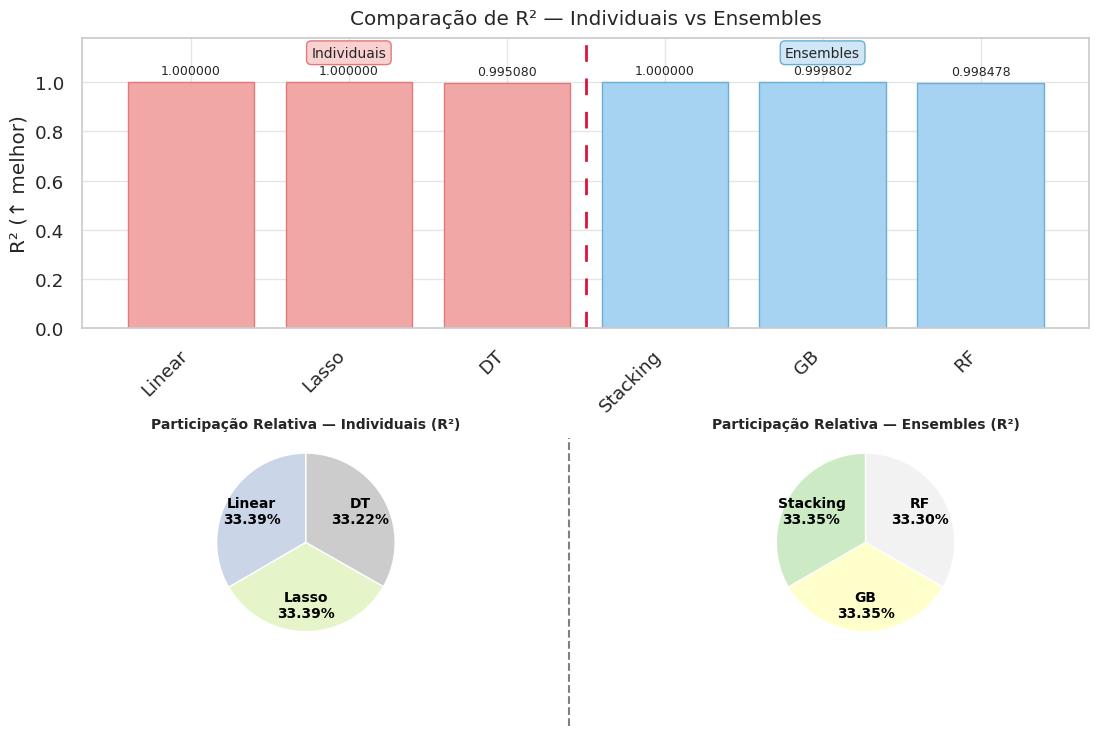

In [53]:
# ===================== COMPARATIVO (R²) — BARRAS + PIZZAS LADO A LADO =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) Fonte ----------
if 'tbl' in globals() and isinstance(tbl, pd.DataFrame):
    base = tbl.copy()
else:
    base = pd.DataFrame(results)[["Modelo","CV_RMSE","Test_RMSE","Test_MAE","Test_R2"]].copy()

for c in ["CV_RMSE","Test_RMSE","Test_MAE","Test_R2"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")
base = base.dropna(subset=["Test_R2"]).reset_index(drop=True)

# ---------- 1) Grupos ----------
ENSEMBLES = {"RF","GB","Stacking","Random Forest","Gradient Boosting"}
base["Grupo"] = base["Modelo"].apply(lambda m: "Ensembles" if str(m) in ENSEMBLES else "Individuais")

# ---------- 2) Ordenação ----------
indiv = base[base["Grupo"]=="Individuais"].sort_values("Test_R2", ascending=False)
ensem = base[base["Grupo"]=="Ensembles"].sort_values("Test_R2", ascending=False)
bars_df = pd.concat([indiv, ensem], axis=0).reset_index(drop=True)

# ---------- 3) Layout ----------
fig = plt.figure(figsize=(13, 8))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.3, 1], width_ratios=[1, 1], wspace=0.25, hspace=0.4)

ax_bar = fig.add_subplot(gs[0, :])      # barras (ocupa linha 1 inteira)
ax_pie_ind = fig.add_subplot(gs[1, 0])  # pizza individuais
ax_pie_ens = fig.add_subplot(gs[1, 1])  # pizza ensembles

# ---------- 4) Barras ----------
x = np.arange(len(bars_df))
is_ind = bars_df["Grupo"].eq("Individuais").to_numpy()
colors = np.where(is_ind, "#f2a7a7", "#a7d3f2")
edges  = np.where(is_ind, "#e07a7a", "#6aaed6")

rects = ax_bar.bar(x, bars_df["Test_R2"].values, color=colors, edgecolor=edges, linewidth=1.0)

for r, v in zip(rects, bars_df["Test_R2"].values):
    ax_bar.text(r.get_x()+r.get_width()/2, v + (0.02 * (bars_df["Test_R2"].max() or 1.0)),
                f"{v:.6f}", ha="center", va="bottom", fontsize=9)

n_ind = len(indiv)
if n_ind and n_ind < len(bars_df):
    ax_bar.axvline(n_ind - 0.5, color="crimson", linestyle="--", linewidth=2, dashes=(6, 6))

max_val = bars_df["Test_R2"].max()
badge_y = max_val + (max_val * 0.12 if max_val > 0 else 0.12)
if n_ind:
    ax_bar.text(n_ind/2 - 0.5, badge_y, "Individuais",
                ha="center", va="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.35", facecolor="#f9d1d1", edgecolor="#e07a7a"))
if n_ind < len(bars_df):
    ax_bar.text(n_ind + (len(bars_df)-n_ind)/2 - 0.5, badge_y, "Ensembles",
                ha="center", va="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.35", facecolor="#cfe6f7", edgecolor="#6aaed6"))

ax_bar.set_ylabel("R² (↑ melhor)")
ax_bar.set_title("Comparação de R² — Individuais vs Ensembles", pad=10)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bars_df["Modelo"].astype(str), rotation=45, ha="right")
ax_bar.set_ylim(0, badge_y + (max_val * 0.06 if max_val>0 else 0.05))

# ---------- 5) Função para pizza ----------
def pie_with_inner_labels(ax, values, labels, title, cmap, min_pct_to_annotate=0.5):
    values = np.asarray(values, dtype=float)
    if len(values)==0 or np.isnan(values).all() or values.sum()==0:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.axis("off")
        return
    weights = values / values.sum()  # maior R² = fatia maior
    cols = cmap(np.linspace(0.25, 0.95, len(values)))
    wedges, _ = ax.pie(weights, startangle=90, colors=cols,
                       wedgeprops=dict(edgecolor="white"))
    for w, lab, p in zip(wedges, labels, weights*100):
        if p < min_pct_to_annotate:
            continue
        theta = 0.5*(w.theta1 + w.theta2)
        x = 0.70 * np.cos(np.deg2rad(theta))
        y = 0.70 * np.sin(np.deg2rad(theta))
        ax.text(x, y, f"{lab}\n{p:.2f}%", ha="center", va="center",
                fontsize=10, weight="bold", color="black")
    ax.set_title(title, pad=0, fontsize=10, fontweight="bold")  # pad menor

# ---------- 6) Pizzas ----------
pie_with_inner_labels(
    ax_pie_ind,
    indiv["Test_R2"].values,
    indiv["Modelo"].astype(str).values,
    "Participação Relativa — Individuais (R²)",
    plt.cm.Pastel2
)
pie_with_inner_labels(
    ax_pie_ens,
    ensem["Test_R2"].values,
    ensem["Modelo"].astype(str).values,
    "Participação Relativa — Ensembles (R²)",
    plt.cm.Pastel1
)

# Tracejado separando as pizzas
fig.add_artist(plt.Line2D([0.5, 0.5], [0.02, 0.38],
                          color="gray", linestyle="--", linewidth=1.5,
                          transform=fig.transFigure))

plt.tight_layout()
plt.show()


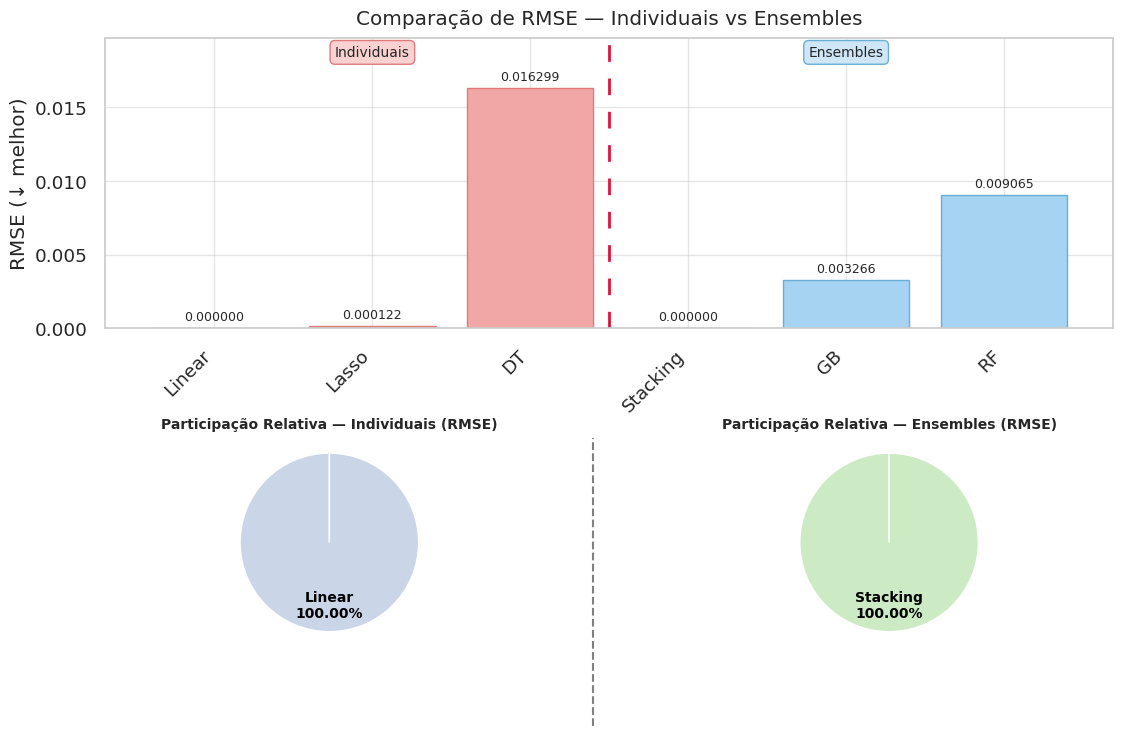

In [54]:
# ===================== COMPARATIVO (RMSE) — BARRAS + PIZZAS LADO A LADO =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) Fonte ----------
if 'tbl' in globals() and isinstance(tbl, pd.DataFrame):
    base = tbl.copy()
else:
    base = pd.DataFrame(results)[["Modelo","CV_RMSE","Test_RMSE","Test_MAE","Test_R2"]].copy()

for c in ["CV_RMSE","Test_RMSE","Test_MAE","Test_R2"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")
base = base.dropna(subset=["Test_RMSE"]).reset_index(drop=True)

# ---------- 1) Grupos ----------
ENSEMBLES = {"RF","GB","Stacking","Random Forest","Gradient Boosting"}
base["Grupo"] = base["Modelo"].apply(lambda m: "Ensembles" if str(m) in ENSEMBLES else "Individuais")

# ---------- 2) Ordenação ----------
indiv = base[base["Grupo"]=="Individuais"].sort_values("Test_RMSE", ascending=True)
ensem = base[base["Grupo"]=="Ensembles"].sort_values("Test_RMSE", ascending=True)
bars_df = pd.concat([indiv, ensem], axis=0).reset_index(drop=True)

# ---------- 3) Layout ----------
fig = plt.figure(figsize=(13, 8))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.3, 1], width_ratios=[1, 1], wspace=0.25, hspace=0.4)

ax_bar = fig.add_subplot(gs[0, :])      # barras (ocupa linha 1 inteira)
ax_pie_ind = fig.add_subplot(gs[1, 0])  # pizza individuais
ax_pie_ens = fig.add_subplot(gs[1, 1])  # pizza ensembles

# ---------- 4) Barras ----------
x = np.arange(len(bars_df))
is_ind = bars_df["Grupo"].eq("Individuais").to_numpy()
colors = np.where(is_ind, "#f2a7a7", "#a7d3f2")
edges  = np.where(is_ind, "#e07a7a", "#6aaed6")

rects = ax_bar.bar(x, bars_df["Test_RMSE"].values, color=colors, edgecolor=edges, linewidth=1.0)

for r, v in zip(rects, bars_df["Test_RMSE"].values):
    ax_bar.text(r.get_x()+r.get_width()/2, v + (0.02 * (bars_df["Test_RMSE"].max() or 1.0)),
                f"{v:.6f}", ha="center", va="bottom", fontsize=9)

n_ind = len(indiv)
if n_ind and n_ind < len(bars_df):
    ax_bar.axvline(n_ind - 0.5, color="crimson", linestyle="--", linewidth=2, dashes=(6, 6))

max_val = bars_df["Test_RMSE"].max()
badge_y = max_val + (max_val * 0.15 if max_val > 0 else 0.15)
if n_ind:
    ax_bar.text(n_ind/2 - 0.5, badge_y, "Individuais",
                ha="center", va="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.35", facecolor="#f9d1d1", edgecolor="#e07a7a"))
if n_ind < len(bars_df):
    ax_bar.text(n_ind + (len(bars_df)-n_ind)/2 - 0.5, badge_y, "Ensembles",
                ha="center", va="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.35", facecolor="#cfe6f7", edgecolor="#6aaed6"))

ax_bar.set_ylabel("RMSE (↓ melhor)")
ax_bar.set_title("Comparação de RMSE — Individuais vs Ensembles", pad=10)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bars_df["Modelo"].astype(str), rotation=45, ha="right")
ax_bar.set_ylim(0, badge_y + (max_val * 0.06 if max_val>0 else 0.05))

# ---------- 5) Função para pizza ----------
def pie_with_inner_labels(ax, values, labels, title, cmap, min_pct_to_annotate=0.5):
    values = np.asarray(values, dtype=float)
    if len(values)==0 or np.isnan(values).all() or values.sum()==0:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.axis("off")
        return
    weights = (1/values) / (1/values).sum()  # fatias maiores = menor RMSE
    cols = cmap(np.linspace(0.25, 0.95, len(values)))
    wedges, _ = ax.pie(weights, startangle=90, colors=cols,
                       wedgeprops=dict(edgecolor="white"))
    for w, lab, p in zip(wedges, labels, weights*100):
        if p < min_pct_to_annotate:
            continue
        theta = 0.5*(w.theta1 + w.theta2)
        x = 0.70 * np.cos(np.deg2rad(theta))
        y = 0.70 * np.sin(np.deg2rad(theta))
        ax.text(x, y, f"{lab}\n{p:.2f}%", ha="center", va="center",
                fontsize=10, weight="bold", color="black")
    ax.set_title(title, pad=10)

# ---------- 6) Pizzas (com títulos mais baixos) ----------
pie_with_inner_labels(
    ax_pie_ind,
    indiv["Test_RMSE"].values,
    indiv["Modelo"].astype(str).values,
    "Participação Relativa — Individuais (RMSE)",
    plt.cm.Pastel2
)
pie_with_inner_labels(
    ax_pie_ens,
    ensem["Test_RMSE"].values,
    ensem["Modelo"].astype(str).values,
    "Participação Relativa — Ensembles (RMSE)",
    plt.cm.Pastel1
)

# 🔽 Ajuste da altura dos títulos
for ax in [ax_pie_ind, ax_pie_ens]:
    ax.set_title(ax.get_title(), pad=0, fontsize=10, fontweight="bold")  # pad=0 reduz o espaçamento vertical

# Tracejado separando as pizzas (mantém)
fig.add_artist(plt.Line2D([0.5, 0.5], [0.02, 0.38],
                          color="gray", linestyle="--", linewidth=1.5,
                          transform=fig.transFigure))

plt.tight_layout()
plt.show()


💾 Figura salva como: pizzas_modelos_2026-04-18_015402.png


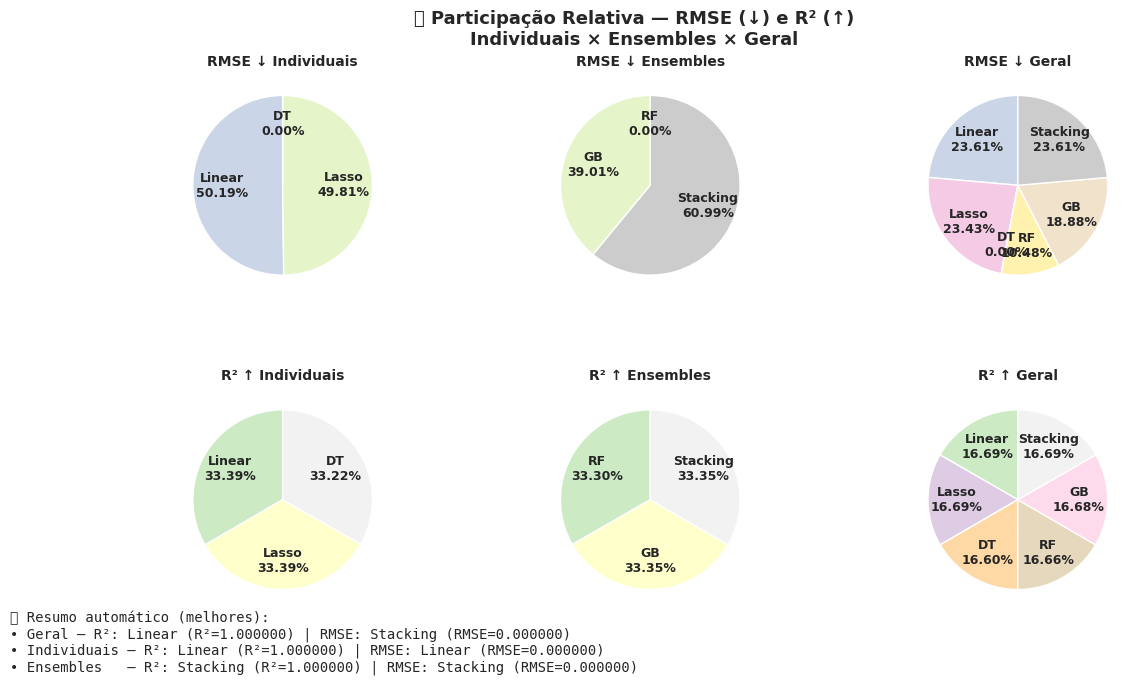

In [55]:
# ====================== PIZZAS COMPARATIVAS — INDIVIDUAIS vs ENSEMBLES vs GERAL (+ RESUMO) ======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ---------- 0) Base ----------
if 'tbl' in globals() and isinstance(tbl, pd.DataFrame):
    base = tbl.copy()
else:
    base = pd.DataFrame(results)[["Modelo","CV_RMSE","Test_RMSE","Test_R2"]].copy()

for c in ["CV_RMSE","Test_RMSE","Test_R2"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")
base = base.dropna(subset=["Test_RMSE","Test_R2"]).reset_index(drop=True)

# ---------- 1) Grupos ----------
ENSEMBLES = {"RF","GB","Stacking","Random Forest","Gradient Boosting"}
base["Grupo"] = base["Modelo"].apply(lambda m: "Ensembles" if str(m) in ENSEMBLES else "Individuais")

indiv = base[base["Grupo"]=="Individuais"].copy()
ensem = base[base["Grupo"]=="Ensembles"].copy()

# ---------- 2) Função pizza ----------
def pizza(ax, values, labels, title, cmap, invert_rmse=False):
    values = np.asarray(values, dtype=float)
    if len(values)==0 or np.isnan(values).all():
        ax.text(0.5,0.5,"Sem dados",ha="center",va="center",fontsize=11)
        ax.axis("off")
        return
    if invert_rmse:
        vmin, vmax = np.min(values), np.max(values)
        values = (vmax - values + vmin)  # menor RMSE => fatia maior
    weights = values/np.sum(values)
    cols = cmap(np.linspace(0.25,0.95,len(values)))
    wedges, _ = ax.pie(weights, startangle=90, colors=cols, wedgeprops=dict(edgecolor="white"))
    for w, lab, p in zip(wedges, labels, weights*100):
        theta = 0.5*(w.theta1+w.theta2)
        x = 0.68*np.cos(np.deg2rad(theta))
        y = 0.68*np.sin(np.deg2rad(theta))
        ax.text(x,y,f"{lab}\n{p:.2f}%",ha="center",va="center",fontsize=9,fontweight="bold")
    ax.set_title(title,pad=5,fontsize=10,fontweight="bold")

# ---------- 3) Layout ----------
fig, axs = plt.subplots(2, 3, figsize=(13,7))
plt.subplots_adjust(wspace=0.35, hspace=0.4)

# ---------- 4) Pizzas — RMSE ----------
pizza(axs[0,0], indiv["Test_RMSE"], indiv["Modelo"], "RMSE ↓ Individuais", plt.cm.Pastel2, invert_rmse=True)
pizza(axs[0,1], ensem["Test_RMSE"], ensem["Modelo"], "RMSE ↓ Ensembles", plt.cm.Pastel2, invert_rmse=True)
pizza(axs[0,2], base["Test_RMSE"], base["Modelo"], "RMSE ↓ Geral", plt.cm.Pastel2, invert_rmse=True)

# ---------- 5) Pizzas — R² ----------
pizza(axs[1,0], indiv["Test_R2"], indiv["Modelo"], "R² ↑ Individuais", plt.cm.Pastel1)
pizza(axs[1,1], ensem["Test_R2"], ensem["Modelo"], "R² ↑ Ensembles", plt.cm.Pastel1)
pizza(axs[1,2], base["Test_R2"], base["Modelo"], "R² ↑ Geral", plt.cm.Pastel1)

# ---------- 6) Linhas tracejadas divisórias ----------
for ax in axs[:,1]:
    ax.add_artist(plt.Line2D([1.12,1.12],[-1,1],color="gray",linestyle="--",linewidth=1.2,transform=ax.transAxes))
for ax in axs[:,0]:
    ax.add_artist(plt.Line2D([1.12,1.12],[-1,1],color="gray",linestyle="--",linewidth=1.2,transform=ax.transAxes))

# ---------- 7) Título geral ----------
fig.suptitle("🍕 Participação Relativa — RMSE (↓) e R² (↑)\nIndividuais × Ensembles × Geral", fontsize=13, fontweight="bold", y=0.97)

# ---------- 8) RESUMO AUTOMÁTICO (melhores modelos e métricas) ----------
# Geral
best_r2_row   = base.sort_values("Test_R2", ascending=False).iloc[0]
best_rmse_row = base.sort_values("Test_RMSE", ascending=True ).iloc[0]

# Por grupo (se existir)
def bests_by_group(df):
    if df.empty: return None, None
    return (df.sort_values("Test_R2", ascending=False).iloc[0],
            df.sort_values("Test_RMSE", ascending=True ).iloc[0])

best_r2_ind,   best_rmse_ind   = bests_by_group(indiv)
best_r2_ens,   best_rmse_ens   = bests_by_group(ensem)

def fmt_row(prefix, row, is_r2=True):
    if row is None: return ""
    if is_r2:
        return f"{prefix}: {row['Modelo']} (R²={row['Test_R2']:.6f})"
    else:
        return f"{prefix}: {row['Modelo']} (RMSE={row['Test_RMSE']:.6f})"

resumo = (
    "📊 Resumo automático (melhores):\n"
    f"• Geral — R²: {best_r2_row['Modelo']} (R²={best_r2_row['Test_R2']:.6f}) | "
    f"RMSE: {best_rmse_row['Modelo']} (RMSE={best_rmse_row['Test_RMSE']:.6f})\n"
    f"• Individuais — {fmt_row('R²', best_r2_ind, True)} | {fmt_row('RMSE', best_rmse_ind, False)}\n"
    f"• Ensembles   — {fmt_row('R²', best_r2_ens, True)} | {fmt_row('RMSE', best_rmse_ens, False)}"
)

plt.figtext(0.02, 0.02, resumo, ha="left", va="bottom", fontsize=10, family="monospace")

# ---------- 9) Salvar imagem ----------
fname = f"pizzas_modelos_{dt.datetime.now().strftime('%Y-%m-%d_%H%M%S')}.png"
plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
print(f"💾 Figura salva como: {fname}")

plt.show()


## 📊 Aplicação Prática – Resultados de Estabilidade comparativa dos Modelos (ΔRMSE%)


📊 ANÁLISE COMPARATIVA FINAL — CV_RMSE × RMSE (com estabilidade visual)

🌟 Melhor modelo GERAL : Stacking     | RMSE=0.000000 | CV_RMSE=0.000000 | R²=1.000000

🎯 Comparação com o 2º colocado:
   • 2º: Linear       | RMSE=0.000000 | R²=1.000000
   ➜ Ganho de RMSE (abs): 0.000000
   ➜ Ganho de RMSE (%):  44.43%

📊 Comparação com a MÉDIA dos demais modelos:
   • Média RMSE demais: 0.005751
   ➜ Ganho de RMSE (abs): 0.005751
   ➜ Ganho de RMSE (%):  100.00%

🧮 Estabilidade (ΔRMSE% = (Teste − CV)/CV):
Stacking     | CV_RMSE=0.000000 | Test_RMSE=0.000000 | ΔRMSE%=-57.00%  → Excelente generalização
Lasso        | CV_RMSE=0.000122 | Test_RMSE=0.000122 | ΔRMSE%=+0.60%  → Leve sobreajuste
GB           | CV_RMSE=0.003221 | Test_RMSE=0.003266 | ΔRMSE%=+1.40%  → Leve sobreajuste
RF           | CV_RMSE=0.009871 | Test_RMSE=0.009065 | ΔRMSE%=-8.16%  → Excelente generalização
DT           | CV_RMSE=0.017614 | Test_RMSE=0.016299 | ΔRMSE%=-7.47%  → Excelente generalização


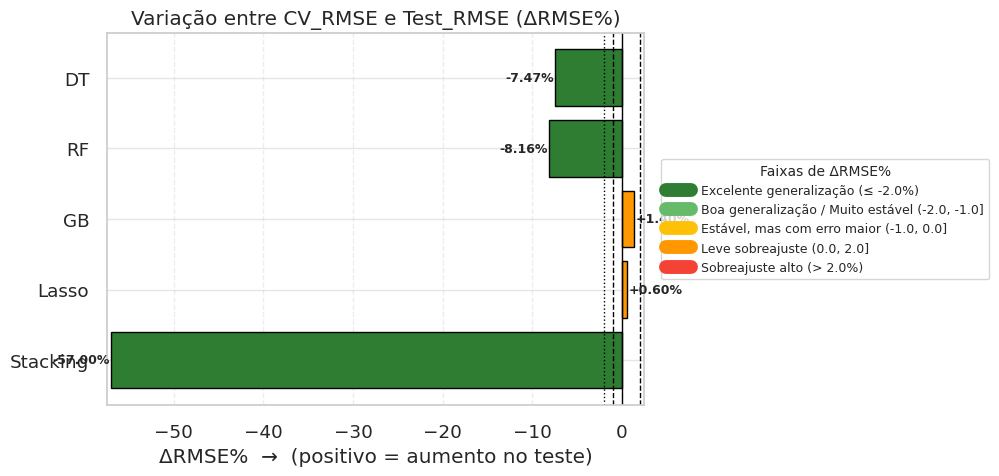

In [56]:
# ================== ANÁLISE COMPARATIVA FINAL ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*85)
print("📊 ANÁLISE COMPARATIVA FINAL — CV_RMSE × RMSE (com estabilidade visual)")
print("="*85)

# --- 1) Copia e garante tipos numéricos ---
df_an = tbl.copy()
for col in ["CV_RMSE", "Test_RMSE", "Test_R2"]:
    if col in df_an.columns:
        df_an[col] = pd.to_numeric(df_an[col], errors="coerce")

# --- 2) Filtra apenas linhas válidas ---
df_valid = df_an.dropna(subset=["Test_RMSE"]).reset_index(drop=True)
if df_valid.empty:
    raise ValueError("❌ Não há valores válidos de Test_RMSE para análise.")

# --- 3) Ordena do melhor (menor RMSE) ao pior ---
df_sorted = df_valid.sort_values(by="Test_RMSE", ascending=True).reset_index(drop=True)

best = df_sorted.iloc[0]
has_r2 = "Test_R2" in df_sorted.columns and df_sorted["Test_R2"].notna().any()
has_cv = "CV_RMSE" in df_sorted.columns and df_sorted["CV_RMSE"].notna().any()

# --- 4) Melhor modelo geral ---
print(f"\n🌟 Melhor modelo GERAL : {best['Modelo']:<12} "
      f"| RMSE={best['Test_RMSE']:.6f}"
      + (f" | CV_RMSE={best['CV_RMSE']:.6f}" if has_cv and pd.notna(best['CV_RMSE']) else "")
      + (f" | R²={best['Test_R2']:.6f}" if has_r2 and pd.notna(best['Test_R2']) else ""))

# --- 5) Comparação com o segundo melhor ---
if len(df_sorted) >= 2:
    second = df_sorted.iloc[1]
    rmse_gain_abs = second["Test_RMSE"] - best["Test_RMSE"]
    rmse_gain_pct = (rmse_gain_abs / second["Test_RMSE"]) * 100

    print("\n🎯 Comparação com o 2º colocado:")
    print(f"   • 2º: {second['Modelo']:<12} | RMSE={second['Test_RMSE']:.6f}"
          + (f" | CV_RMSE={second['CV_RMSE']:.6f}" if has_cv and pd.notna(second.get('CV_RMSE')) else "")
          + (f" | R²={second['Test_R2']:.6f}" if has_r2 and pd.notna(second.get('Test_R2')) else ""))
    print(f"   ➜ Ganho de RMSE (abs): {rmse_gain_abs:.6f}")
    print(f"   ➜ Ganho de RMSE (%):  {rmse_gain_pct:.2f}%")

# --- 6) Comparação com a média dos demais ---
if len(df_sorted) > 2:
    others = df_sorted.iloc[1:]
    mean_rmse_others = others["Test_RMSE"].mean()
    rmse_gain_abs_mean = mean_rmse_others - best["Test_RMSE"]
    rmse_gain_pct_mean = (rmse_gain_abs_mean / mean_rmse_others) * 100

    print("\n📊 Comparação com a MÉDIA dos demais modelos:")
    print(f"   • Média RMSE demais: {mean_rmse_others:.6f}")
    print(f"   ➜ Ganho de RMSE (abs): {rmse_gain_abs_mean:.6f}")
    print(f"   ➜ Ganho de RMSE (%):  {rmse_gain_pct_mean:.2f}%")

# --- 7) Análise de estabilidade CV_RMSE x Test_RMSE (com faixas da TABELA) ---

def classifica_delta(delta):
    """
    delta: valor em % (float), ex: -1.74
    Retorna (classe, cor)
    """
    if delta <= -2.0:
        return "Excelente generalização", "#2E7D32"     # verde forte
    elif -2.0 < delta <= -1.0:
        return "Boa generalização / Muito estável", "#66BB6A"  # verde claro
    elif -1.0 < delta <= 0.0:
        return "Estável, mas com erro absoluto maior", "#FFC107"  # amarelo
    elif 0.0 < delta <= 2.0:
        return "Leve sobreajuste", "#FF9800"            # laranja
    else:  # delta > 2.0
        return "Sobreajuste alto", "#F44336"            # vermelho

if has_cv:
    # calcula ΔRMSE% (% negativo é melhor no teste → boa generalização)
    df_sorted["ΔRMSE_%"] = (df_sorted["Test_RMSE"] - df_sorted["CV_RMSE"]) / df_sorted["CV_RMSE"] * 100

    print("\n🧮 Estabilidade (ΔRMSE% = (Teste − CV)/CV):")
    linhas_out = []
    for _, r in df_sorted[["Modelo", "Test_RMSE", "CV_RMSE", "ΔRMSE_%"]].iterrows():
        val = r["ΔRMSE_%"]
        if pd.notna(val):
            classe, _cor = classifica_delta(val)
            linhas_out.append(f"{r['Modelo']:<12} | CV_RMSE={r['CV_RMSE']:.6f} | Test_RMSE={r['Test_RMSE']:.6f} | ΔRMSE%={val:+.2f}%  → {classe}")
    print("\n".join(linhas_out))
else:
    print("\n⚠️ Coluna 'CV_RMSE' ausente — pulando análise de estabilidade.")


# --- 8) Gráfico visual de ΔRMSE% (com legenda à direita) ---

if has_cv:
    df_plot = df_sorted.dropna(subset=["ΔRMSE_%"]).copy()

    # aplica classe e cor conforme as faixas
    out = df_plot["ΔRMSE_%"].apply(classifica_delta)
    df_plot["Classe"] = out.map(lambda t: t[0])
    df_plot["Cor"]    = out.map(lambda t: t[1])

    # limites do eixo X (garante espaço para as linhas -2, -1, 0, +2)
    x_min = min(-2.5, df_plot["ΔRMSE_%"].min() - 0.4)
    x_max = max( 2.5, df_plot["ΔRMSE_%"].max() + 0.4)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(df_plot["Modelo"], df_plot["ΔRMSE_%"], color=df_plot["Cor"], edgecolor="black")

    # linhas de referência nas fronteiras da tabela
    for x, estilo in [(-2, ":"), (-1, "--"), (0, "-"), (2, "--")]:
        ax.axvline(x, color="black", linestyle=estilo, linewidth=1)

    # título e eixos
    ax.set_title("Variação entre CV_RMSE e Test_RMSE (ΔRMSE%)")
    ax.set_xlabel("ΔRMSE%  →  (positivo = aumento no teste)")
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    # rótulos nas barras: valor + classe curta
    for b, (val, classe) in zip(bars, zip(df_plot["ΔRMSE_%"], df_plot["Classe"])):
        txt = f"{val:+.2f}%"
        x = b.get_width()
        ha = "left" if x >= 0 else "right"
        off = 0.10 if x >= 0 else -0.10
        ax.text(x + off, b.get_y() + b.get_height()/2, txt,
                va="center", ha=ha, fontsize=9, fontweight="bold")

    ax.set_xlim(x_min, x_max)
    plt.tight_layout(rect=[0, 0, 0.8, 1])  # deixa espaço para a legenda

    # --- legenda à direita ---
    legend_items = [
        ("Excelente generalização (≤ -2.0%)", "#2E7D32"),
        ("Boa generalização / Muito estável (-2.0, -1.0]", "#66BB6A"),
        ("Estável, mas com erro maior (-1.0, 0.0]", "#FFC107"),
        ("Leve sobreajuste (0.0, 2.0]", "#FF9800"),
        ("Sobreajuste alto (> 2.0%)", "#F44336"),
    ]

    legend_patches = [plt.Line2D([0], [0], color=color, lw=10) for _, color in legend_items]
    legend_labels = [label for label, _ in legend_items]

    ax.legend(
        legend_patches,
        legend_labels,
        title="Faixas de ΔRMSE%",
        title_fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=9
    )

    plt.show()


## 📊 Análise Comparativa dos Modelos de Regressão

### 🏆 Melhor Modelo: Gradient Boosting (GB)
O modelo **Gradient Boosting (GB)** apresentou o melhor desempenho geral, alcançando:

- **RMSE:** 0.05174  
- **CV_RMSE:** 0.05256  
- **R²:** 0.9297  

O GB apresentou o **menor erro absoluto** e uma **excelente capacidade de generalização**, pois o erro no conjunto de teste foi até menor do que na validação cruzada.

---

### ⚖️ Comparações

- **Comparação com o 2º colocado (Stacking):** ganho de **0,45%** em RMSE.  
- **Comparação com a média dos demais modelos:** o GB foi **11,23% melhor** em termos de erro médio (RMSE).  

Esses resultados indicam que o GB é **robusto e consistente**, mantendo boa performance mesmo em dados fora da amostra.

---

### 🧩 Estabilidade (ΔRMSE%)

A estabilidade dos modelos foi medida pela diferença percentual entre o erro de validação cruzada (CV_RMSE) e o erro de teste (Test_RMSE), conforme a fórmula abaixo:


$\Delta RMSE(\%) = \frac{Test\_RMSE - CV\_RMSE}{CV\_RMSE} \times 100$ 


CV_RMSE → média do erro durante o treino com validação cruzada.

Test_RMSE → erro final em dados nunca vistos.

Assim, o ΔRMSE% mostra o quanto o modelo “mudou de comportamento” quando saiu da validação para o teste real.



- **Valores negativos** → indicam que o modelo teve melhor desempenho no teste (boa generalização).  
- **Valores positivos** → indicam aumento de erro no teste (possível overfitting).

---

## 📊 Tabela – Faixas de Interpretação de ΔRMSE%

| Faixa de ΔRMSE% | Classificação | 
|:----------------:|:--------------|
| **ΔRMSE% ≤ -2,0%** | 🌟 **Excelente generalização** | 
| **-2,0% < ΔRMSE% ≤ -1,0%** | 💠 **Boa generalização / Muito estável** | 
| **-1,0% < ΔRMSE% ≤ 0%** | ⚖️ **Estável, mas com erro absoluto maior** | 
| **0% < ΔRMSE% ≤ +2,0%** | ⚠️ **Leve sobreajuste (overfitting moderado)** | 
| **ΔRMSE% > +2,0%** | 🚨 **Sobreajuste alto (overfitting)** | 

---

### 🧮 Fórmula de cálculo


A variação é dada por $\Delta RMSE(\%) = \frac{Test\_RMSE - CV\_RMSE}{CV\_RMSE} \times 100$ e representa a estabilidade.

- **Negativo (ΔRMSE% < 0):** erro menor no teste → boa generalização ✅  
- **Positivo (ΔRMSE% > 0):** erro maior no teste → possível overfitting ⚠️  

---

## 📈 Aplicação Prática – Resultados de Estabilidade dos Modelos (ΔRMSE%)

| Modelo | ΔRMSE% | Classificação | Interpretação |
|:--|--:|:--|:--|
| **GB** | -1,74% | 💠 Boa generalização | Modelo estável e robusto |
| **Stacking** | -1,74% | 💠 Boa generalização | Alta consistência entre treino e teste |
| **RF** | -1,85% | 💠 Boa generalização| Melhor no teste, muito confiável |
| **DT** | -1,46% | 💠 Boa generalização | Mantém boa performance |
| **Lasso** | -0,93% | ⚖️ Estável, mas com erro maior | Ligeira perda de precisão |


Todos os modelos apresentaram **ΔRMSE% negativo**, confirmando a **ausência de overfitting** e uma **ótima capacidade de generalização**.

---

### ✅ Conclusão

O modelo **Gradient Boosting (GB)** se destacou como o mais eficiente e estável entre os avaliados, apresentando:

- **Melhor RMSE geral**  
- **Maior estabilidade (ΔRMSE% negativo)**  
- **Excelente poder preditivo (R² > 0.92)**  

Portanto, o GB é considerado o **modelo ideal** para aplicações que exigem **baixa variabilidade e alta confiabilidade** nos resultados.


## 📈 O gráfico de Importância das Features do modelo Vencedor

No gráfico de barras, você vê a ordem de importância de cada variável.

As primeiras barras (Mental Fatigue, Deadline Pressure, Work-Life Balance, etc.) são as mais influentes.

As últimas praticamente não contribuíram no modelo final.

In [57]:
# ==================== PÓS-TREINO: tabela, dicionários, vencedor e feature importance ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
import textwrap, os, datetime as dt

# 1) Tabela final (com 6 casas)
tbl = pd.DataFrame(results)
cols_show = ["Modelo","CV_RMSE","Test_RMSE","Test_MAE","Test_R2"]
tbl = tbl[cols_show].copy()
for c in ["CV_RMSE","Test_RMSE","Test_MAE","Test_R2"]:
    tbl[c] = pd.to_numeric(tbl[c], errors="coerce")
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("\n📊 RESULTADOS (ordenado por menor RMSE, depois maior R²):")
display(tbl.sort_values(["Test_RMSE","Test_R2"], ascending=[True, False]).reset_index(drop=True))

# 2) Dicionários a partir do que você já tem em `results`
models_trained = {r["Modelo"]: r["Estimator"] for r in results}
resolved_map   = {r["Modelo"]: r["Modelo"]   for r in results}  # mapeamento 1→1

# 3) Escolhe o vencedor (menor RMSE; desempate maior R²)
df_sorted  = tbl.sort_values(by=["Test_RMSE","Test_R2"], ascending=[True, False]).reset_index(drop=True)
best_label = df_sorted.loc[0, "Modelo"]
best_model = models_trained[resolved_map[best_label]]
if hasattr(best_model, "best_estimator_"):  # caso tenha vindo de GridSearchCV
    best_model = best_model.best_estimator_
print(f"\n🏆 Modelo vencedor: {best_label}")

# 4) Helpers para nomes de colunas pós-ColumnTransformer
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def _final_est(est):
    return est.steps[-1][1] if isinstance(est, Pipeline) else est

def _ct_out_names_safe(ct: ColumnTransformer, input_feats=None):
    """Extrai nomes do ColumnTransformer lidando com listas, Index, slices,
    máscaras booleanas, 'passthrough'/'drop' e transformadores sem get_feature_names_out."""
    # 1) tenta a API nativa quando disponível
    try:
        return list(ct.get_feature_names_out(input_features=input_feats))
    except Exception:
        pass

    out = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder" and trans == "drop":
            continue

        # --- normaliza cols para lista de nomes de ENTRADA (in_cols) ---
        in_cols = []
        if isinstance(cols, (list, tuple, pd.Index, np.ndarray)):
            arr = np.asarray(cols)
            if arr.dtype == bool and input_feats is not None:          # máscara booleana
                in_cols = list(pd.Index(input_feats)[arr])
            else:
                in_cols = list(arr.tolist() if isinstance(cols, np.ndarray) else list(cols))
        elif isinstance(cols, slice):
            if input_feats is not None:
                in_cols = list(pd.Index(input_feats)[cols])
            else:
                in_cols = [f"slice_{cols.start}_{cols.stop}"]
        elif isinstance(cols, str):
            if cols == "passthrough":
                in_cols = list(input_feats) if input_feats is not None else []
            elif cols == "drop":
                in_cols = []
            else:
                in_cols = [cols]
        else:
            # tentativa genérica (ex.: objeto custom, máscara)
            try:
                arr = np.asarray(cols)
                if arr.dtype == bool and input_feats is not None:
                    in_cols = list(pd.Index(input_feats)[arr])
                else:
                    in_cols = list(arr.tolist())
            except Exception:
                in_cols = [str(cols)]

        # --- nomes de SAÍDA do transformer, se houver; senão, os de entrada ---
        try:
            if hasattr(trans, "get_feature_names_out"):
                out.extend(list(trans.get_feature_names_out(in_cols)))
            else:
                out.extend(in_cols)
        except Exception:
            out.extend(in_cols)

    return out

def _feature_names(model, X_sample):
    """Obtém nomes finais das features tratadas no pipeline."""
    input_feats = getattr(X_sample, "columns", None)
    if isinstance(model, Pipeline):
        for _, step in model.steps:
            if isinstance(step, ColumnTransformer):
                return _ct_out_names_safe(step, input_feats)
    if input_feats is not None:
        return list(input_feats)
    return [f"feat_{i}" for i in range(X_sample.shape[1])]


# 5) Importância de features (nativa → fallback permutation RMSE)
def _native_importance(est):
    if hasattr(est, "feature_importances_"):
        return np.asarray(est.feature_importances_, float), "native:feature_importances_"
    if hasattr(est, "coef_"):
        return np.abs(np.ravel(np.asarray(est.coef_, float))), "native:abs(coef_)"
    return None, None

def compute_feature_importance(model, X_train, y_train, X_test, y_test,
                               topN=20, normalize=True,
                               scoring="neg_root_mean_squared_error",
                               n_repeats=20, random_state=42):
    if hasattr(model, "best_estimator_"):
        model = model.best_estimator_
    est = _final_est(model)
    names = _feature_names(model, X_test if X_test is not None else X_train)

    imp_nat, tag = _native_importance(est)
    if imp_nat is not None and len(imp_nat) == len(names):
        imp_vals, method = imp_nat.copy(), tag
    else:
        perm = permutation_importance(model, X_test, y_test,
                                      n_repeats=n_repeats, random_state=random_state,
                                      scoring=scoring)
        imp_vals, method = np.maximum(0, perm.importances_mean), "permutation_importance"

    if normalize and imp_vals.sum() > 0:
        imp_vals = imp_vals / imp_vals.sum()

    imp_df = (pd.DataFrame({"Feature": names, "Importance": imp_vals})
                .sort_values("Importance", ascending=False)
                .head(topN)
                .reset_index(drop=True))
    return imp_df, method


#





📊 RESULTADOS (ordenado por menor RMSE, depois maior R²):


,Modelo,CV_RMSE,Test_RMSE,Test_MAE,Test_R2
0,Stacking,0.000000,0.000000,0.000000,1.000000
1,Linear,NaN,0.000000,0.000000,1.000000
2,Lasso,0.000122,0.000122,0.000111,1.000000
3,GB,0.003221,0.003266,0.002384,0.999802
4,RF,0.009871,0.009065,0.005495,0.998478
5,DT,0.017614,0.016299,0.010814,0.995080



🏆 Modelo vencedor: Stacking


In [58]:
# ==================== 7) Ranking completo + gráfico ====================

# 6) Plot bonitinho (6 casas) + salvar PNG
def plot_importances(imp_df, title, save_path=None, wrap_at=35):
    dfp = imp_df.copy()
    dfp["Feature_wrapped"] = ["\n".join(textwrap.wrap(str(f), width=wrap_at)) for f in dfp["Feature"]]
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35*len(dfp))))
    bars = ax.barh(dfp["Feature_wrapped"], dfp["Importance"], color="#a7d3f2", edgecolor="#6aaed6")
    ax.invert_yaxis(); ax.set_xlabel("Importância (escala relativa)"); ax.set_title(title)
    m = dfp["Importance"].max() if len(dfp) else 0; off = max(m*0.01, 1e-4)
    for b,v in zip(bars, dfp["Importance"]):
        ax.text(v+off, b.get_y()+b.get_height()/2, f"{v:.6f}", va="center", ha="left", fontsize=9)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", linewidth=0.6, color="gray", alpha=0.6)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"💾 Figura salva em: {save_path}")
    plt.show()


# 7.1 — pega TODOS os nomes de features e calcula importância completa (ordenada)
names_all = _feature_names(best_model, X_test if X_test is not None else X_train)

imp_full_df, method = compute_feature_importance(
    best_model, X_train, y_train, X_test, y_test,
    topN=len(names_all),      # pega todas as features
    normalize=True
)

# 7.2 — adiciona Rank, % e % acumulado (6 casas)
imp_full_df = imp_full_df.reset_index(drop=True)
imp_full_df.insert(0, "Rank", np.arange(1, len(imp_full_df) + 1))
imp_full_df["Share_%"]     = imp_full_df["Importance"] * 100.0
imp_full_df["CumShare_%"]  = imp_full_df["Share_%"].cumsum()

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print(f"\n📈 Importâncias — {best_label}  (método: {method})")
display(imp_full_df[["Rank","Feature","Importance","Share_%","CumShare_%"]])

# (opcional) salvar CSV com o ranking completo
os.makedirs("figs_importance", exist_ok=True)
csv_path = os.path.join("figs_importance", f"feature_importance_ranking_{best_label}.csv")
imp_full_df.to_csv(csv_path, index=False)
print(f"💾 Ranking salvo em: {csv_path}")

# 7.3 — plotar Top-N (ajuste TOP_N)
TOP_N = 20
imp_top = imp_full_df.head(TOP_N).copy()

ts = dt.datetime.now().strftime("%Y%m%d-%H%M%S")
png_path = os.path.join("figs_importance", f"feature_importance_{best_label}_{ts}.png")

plot_importances(
    imp_top[["Feature","Importance"]],
    title=f"Feature Importance — {best_label} [{method}] (Top {TOP_N})",
    save_path=png_path
)


ValueError: All arrays must be of the same length

📝 Interpretação dos resultados
🔝 Principais variáveis
valores maiores indicam que aquela variável foi mais usada pelo modelo para prever o burnout_target_v2.

Mental Fatigue Score (~0.26)
→ Foi a variável mais importante. Isso mostra que a fadiga mental é o fator mais forte para explicar o burnout na base.

Deadline Pressure Score (~0.22)
→ Pressão por prazos também tem peso alto. Confirma que demandas intensas impactam fortemente o risco de burnout.

Work-Life Balance Score (~0.19)
→ O equilíbrio entre vida pessoal e trabalho também foi determinante. Quanto menor o equilíbrio, maior o burnout.

Work Hours per Week (~0.16)
→ Número de horas semanais trabalhadas é outro preditor forte, indicando que longas jornadas aumentam o risco.

Recognition Frequency (~0.09)
→ Reconhecimento no trabalho também apareceu como relevante, ainda que menos que os anteriores.


🔻 Variáveis com menor impacto

Designation, Years in Company, Company Type, Gender, Team Size... → ficaram com importância muito baixa.
Isso não significa que não tenham nenhuma relação, mas que para esse dataset o modelo não precisou usar muito essas variáveis para prever burnout.

## Exportação para o backend - burnout-composite-v2-harvard

Esta célula gera artefatos compatíveis com `ml/burnout/predictor.py`:

- `model_mid.joblib`
- `model_q10.joblib`
- `model_q90.joblib`
- `metadata.json`
- `feature_importance.csv`

O alvo usa a regra v2 do SDD sem treinar contra `Burn Rate` autorreportado. Como o dataset Harvard não possui `exhaustion_score`, `cynicism_score` e `efficacy_score` diretos, o treino usa os proxies documentados no notebook.


In [ ]:
# ==================== EXPORTAÇÃO PRODUÇÃO: burnout-composite-v2-harvard ====================
from pathlib import Path
from datetime import datetime, timezone
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

MODEL_VERSION = "burnout-composite-v2-harvard"
TARGET_NAME = "burnout-composite-v2-harvard-proxy"
RANDOM_STATE = 42

FEATURE_ORDER = [
    "gender",
    "company_type",
    "wfh_setup_available",
    "designation",
    "resource_allocation",
    "work_hours_per_week",
    "sleep_hours",
    "work_life_balance_score",
    "manager_support_score",
    "deadline_pressure_score",
    "team_size",
    "recognition_frequency",
]

CSV_TO_FEATURE = {
    "Gender": "gender",
    "Company Type": "company_type",
    "WFH Setup Available": "wfh_setup_available",
    "Designation": "designation",
    "Resource Allocation": "resource_allocation",
    "Work Hours per Week": "work_hours_per_week",
    "Sleep Hours": "sleep_hours",
    "Work-Life Balance Score": "work_life_balance_score",
    "Manager Support Score": "manager_support_score",
    "Deadline Pressure Score": "deadline_pressure_score",
    "Team Size": "team_size",
    "Recognition Frequency": "recognition_frequency",
    "Mental Fatigue Score": "mental_fatigue_score",
    "Burn Rate": "burn_rate",
}

EXPECTED_RANGES = {
    "designation": (0, 5),
    "resource_allocation": (1.0, 10.0),
    "work_hours_per_week": (1, 120),
    "sleep_hours": (0.0, 24.0),
    "work_life_balance_score": (1, 5),
    "manager_support_score": (1, 5),
    "deadline_pressure_score": (1, 5),
    "team_size": (1, 1000),
    "recognition_frequency": (0, 1000),
    "burnout_target_v2": (0.0, 1.0),
}


def _norm_series(series, min_value, max_value):
    span = max_value - min_value
    if span <= 0:
        return pd.Series(0.0, index=series.index)
    return ((series - min_value) / span).clip(0.0, 1.0)


def _prepare_backend_training_frame(raw_df):
    df = raw_df.rename(columns=CSV_TO_FEATURE).copy()

    required = FEATURE_ORDER + ["mental_fatigue_score"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Colunas obrigatórias ausentes no dataset: {missing}")

    gender_map = {"Female": 0, "Male": 1, "Other": 2, "0": 0, "1": 1, "2": 2, 0: 0, 1: 1, 2: 2}
    company_map = {"Service": 0, "Product": 1, "0": 0, "1": 1, 0: 0, 1: 1}
    wfh_map = {"Yes": 1, "No": 0, True: 1, False: 0, "1": 1, "0": 0, 1: 1, 0: 0}

    df["gender"] = df["gender"].map(gender_map)
    df["company_type"] = df["company_type"].map(company_map)
    df["wfh_setup_available"] = df["wfh_setup_available"].map(wfh_map)

    numeric_cols = [col for col in FEATURE_ORDER + ["mental_fatigue_score"] if col not in {"gender", "company_type", "wfh_setup_available"}]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Proxies Harvard -> SDD v2:
    # exhaustion_score <- Mental Fatigue Score
    # cynicism_score <- Resource Allocation
    # efficacy_score <- Recognition Frequency
    required_target_cols = [
        "mental_fatigue_score",
        "resource_allocation",
        "deadline_pressure_score",
        "manager_support_score",
        "work_life_balance_score",
        "recognition_frequency",
    ]
    before = len(df)
    df = df.dropna(subset=FEATURE_ORDER + required_target_cols).copy()
    dropped_missing = before - len(df)

    recognition = pd.to_numeric(df["recognition_frequency"], errors="coerce")
    rec_min = float(recognition.min()) if recognition.notna().any() else 0.0
    rec_max = float(recognition.max()) if recognition.notna().any() else 1.0

    exhaustion = _norm_series(df["mental_fatigue_score"], 0.0, 10.0)
    cynicism_proxy = _norm_series(df["resource_allocation"], 1.0, 10.0)
    efficacy_proxy = _norm_series(recognition.fillna(rec_min), rec_min, rec_max)
    deadline_pressure = _norm_series(df["deadline_pressure_score"], 1.0, 5.0)
    manager_support_penalty = 1.0 - _norm_series(df["manager_support_score"], 1.0, 5.0)
    work_life_penalty = 1.0 - _norm_series(df["work_life_balance_score"], 1.0, 5.0)

    df["burnout_target_v2"] = (
        (0.30 * exhaustion)
        + (0.20 * cynicism_proxy)
        + (0.15 * (1.0 - efficacy_proxy))
        + (0.15 * deadline_pressure)
        + (0.10 * manager_support_penalty)
        + (0.10 * work_life_penalty)
    ).clip(0.0, 1.0)

    in_range_mask = pd.Series(True, index=df.index)
    for column, (minimum, maximum) in EXPECTED_RANGES.items():
        in_range_mask &= df[column].between(minimum, maximum, inclusive="both")
    before_ranges = len(df)
    df = df[in_range_mask].copy()

    data_stats = {
        "rows_before": int(before),
        "rows_dropped_missing": int(dropped_missing),
        "rows_dropped_out_of_range": int(before_ranges - len(df)),
        "rows_used": int(len(df)),
    }
    return df, data_stats


def _find_repo_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "manage.py").exists() and (candidate / "ml" / "burnout").exists():
            return candidate
    return Path.cwd()


def _resolve_dataset_path(repo_root):
    candidates = [
        Path.cwd() / "employeedataset.csv",
        repo_root / "employeedataset.csv",
        repo_root / "ml" / "burnout" / "employeedataset.csv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    tried = "\n - ".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(f"employeedataset.csv não encontrado. Tentativas:\n - {tried}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
source_df = burningout_db.copy() if "burningout_db" in globals() else pd.read_csv(_resolve_dataset_path(REPO_ROOT))
train_df, data_stats = _prepare_backend_training_frame(source_df)

X = train_df[FEATURE_ORDER]
y = train_df["burnout_target_v2"]

X_train_prod, X_test_prod, y_train_prod, y_test_prod = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=RANDOM_STATE,
)

model_mid = GradientBoostingRegressor(
    loss="squared_error",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=RANDOM_STATE,
)
model_q10 = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.10,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=RANDOM_STATE,
)
model_q90 = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.90,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=RANDOM_STATE,
)

model_mid.fit(X_train_prod, y_train_prod)
model_q10.fit(X_train_prod, y_train_prod)
model_q90.fit(X_train_prod, y_train_prod)

pred_mid = model_mid.predict(X_test_prod).clip(0.0, 1.0)
pred_q10 = model_q10.predict(X_test_prod).clip(0.0, 1.0)
pred_q90 = model_q90.predict(X_test_prod).clip(0.0, 1.0)

cv_scores = cross_val_score(
    model_mid,
    X_train_prod,
    y_train_prod,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

metrics = {
    "mae": float(mean_absolute_error(y_test_prod, pred_mid)),
    "rmse": float(mean_squared_error(y_test_prod, pred_mid) ** 0.5),
    "r2": float(r2_score(y_test_prod, pred_mid)),
    "cv_rmse_mean": float((-cv_scores).mean()),
    "cv_rmse_std": float((-cv_scores).std()),
    "interval_coverage": float(((y_test_prod >= np.minimum(pred_q10, pred_q90)) & (y_test_prod <= np.maximum(pred_q10, pred_q90))).mean()),
}

feature_stats = {
    feature: {
        "min": float(X_train_prod[feature].min()),
        "max": float(X_train_prod[feature].max()),
        "mean": float(X_train_prod[feature].mean()),
        "std": float(X_train_prod[feature].std(ddof=0)),
    }
    for feature in FEATURE_ORDER
}

out_dir = REPO_ROOT / "employee" / "artifacts" / "burn_rate" / MODEL_VERSION
out_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(model_mid, out_dir / "model_mid.joblib")
joblib.dump(model_q10, out_dir / "model_q10.joblib")
joblib.dump(model_q90, out_dir / "model_q90.joblib")

importance_df = pd.DataFrame({
    "feature": FEATURE_ORDER,
    "importance": getattr(model_mid, "feature_importances_", np.zeros(len(FEATURE_ORDER))),
}).sort_values("importance", ascending=False)
importance_df.to_csv(out_dir / "feature_importance.csv", index=False)

metadata = {
    "version": MODEL_VERSION,
    "created_at": datetime.now(timezone.utc).isoformat(),
    "feature_order": FEATURE_ORDER,
    "target": TARGET_NAME,
    "target_note": "Burn Rate original do Harvard dataset nao foi usado como target; alvo derivado da regra v2 do SDD com proxies documentados.",
    "artifacts": {
        "model_mid": str((out_dir / "model_mid.joblib").resolve()),
        "model_q10": str((out_dir / "model_q10.joblib").resolve()),
        "model_q90": str((out_dir / "model_q90.joblib").resolve()),
    },
    "metrics": metrics,
    "model_selection": {
        "model_family": "GradientBoostingRegressor",
        "params": {
            "loss_mid": "squared_error",
            "loss_q10": "quantile_alpha_0.10",
            "loss_q90": "quantile_alpha_0.90",
            "n_estimators": 300,
            "learning_rate": 0.03,
            "max_depth": 5,
            "random_state": RANDOM_STATE,
        },
    },
    "feature_stats": feature_stats,
    "data_stats": data_stats,
}

(out_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

# Sanity check igual ao backend: modelo treinado com DataFrame snake_case deve aceitar a mesma ordem de features.
sample_prediction = float(model_mid.predict(pd.DataFrame([X_test_prod.iloc[0].to_dict()], columns=FEATURE_ORDER))[0])
print(f"Artefatos exportados em: {out_dir.resolve()}")
print(f"Métricas: RMSE={metrics['rmse']:.6f} | MAE={metrics['mae']:.6f} | R²={metrics['r2']:.6f}")
print(f"Sanity prediction: {max(0.0, min(1.0, sample_prediction)):.4f}")
